# Marbl Energy - Pipeline Summary

Day-ahead electricity price forecasting for **DK1**, **ES**, and **NO2**.

The notebook calls only functions from `src/`.

| Section | Content |
|---|---|
| 1 · Data Ingestion | Download price CSVs and ERA5 weather (guarded - skips if already present) |
| 2 · Feature Engineering | Build mastersets; validate; summarise |
| 3 · Clustering | Ward hierarchical clustering; centroid plots; calendar heatmaps |
| 4 · Model Training | Layer 1 cluster classifier; Layer 2 per-cluster regressors; naive baselines |
| 5 · Evaluation | Cluster-model, Naive-1 and Naive-2 WAPE across all zones |
| 6 · Sanity Checks | Cluster sizes; WAPE range; hourly coverage |


In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import os
from dotenv import load_dotenv
import cdsapi

# ----------------- Locate project root and register src/ on the path -----------------
_probe = Path.cwd()
while not (_probe / 'src').exists() and _probe != _probe.parent:
    _probe = _probe.parent
if str(_probe) not in sys.path:
    sys.path.insert(0, str(_probe))

from src.utils import get_project_root, load_secrets, add_dates_to_output, ZONE_SHORT_CODE
from src.ingestion import (
    fetch_entsoe_range, download_era5_month, process_and_save_forecasts,
    ERA5_ZONE_COORDS,
)
from src.features import (
    process_era5_netcdf, prepare_price_data, build_masterset,
    make_daily_values, make_cluster_pred, add_weekend_dummy, add_season_dummies,
    add_precipitation_last_x_days, attach_cluster, days_not_24_entries,
)
from src.clustering import (
    run_zone_clustering, plot_cluster_centroids, plot_cluster_calendar_for_year,
)
from src.models import (
    train_xgb_classifier, save_cluster_model_bundle,
    xgb_price_within_cluster, predict_cluster_probabilities,
    weighted_price_prediction, naive_approach_one, train_naive_weather_model,
)
from src.evaluation import mae_smape_wape, avg_errors, build_results_table, plot_hourly_series

print('All imports OK.')


All imports OK.


In [2]:
ROOT          = get_project_root()
RAW_DIR       = ROOT / 'data' / 'raw'
CLEAN_DIR     = ROOT / 'data' / 'clean'
PROCESSED_DIR = ROOT / 'data' / 'processed'
MODELS_DIR    = ROOT / 'data' / 'models'
LIVE_DIR      = ROOT / 'data' / 'live'

MODELS_DIR.mkdir(parents=True, exist_ok=True)

# ----------------- Zone configuration - single source of truth -----------------
ZONES = {
    'DK1': {
        'entsoe_code': '10YDK-1--------W',
        'k_focus':     6,
        'best_p':      20,
        'era5_years':  [2023, 2024, 2025],
        'era5_coords': ERA5_ZONE_COORDS['DK1'],
        'cities':      ['Copenhagen', 'Aarhus'],
        'eval_cutoff': pd.Timestamp('2025-06-18'),
    },
    'ES': {
        'entsoe_code': '10YES-REE------0',
        'k_focus':     3,
        'best_p':      20,
        'era5_years':  [2023, 2024, 2025],
        'era5_coords': ERA5_ZONE_COORDS['ES'],
        'cities':      ['Madrid', 'Barcelona'],
        'eval_cutoff': pd.Timestamp('2025-06-20'),
    },
    'NO2': {
        'entsoe_code': '10YNO-2--------T',
        'k_focus':     5,
        'best_p':      7,
        'era5_years':  [2023, 2024, 2025],
        'era5_coords': ERA5_ZONE_COORDS['NO2'],
        'cities':      ['Kristiansand', 'Stavanger'],
        'eval_cutoff': pd.Timestamp('2025-06-20'),
    },
}

print(f'Project root : {ROOT}')
print(f'Zones        : {list(ZONES)}')
print(f'Short codes  : {ZONE_SHORT_CODE}')


Project root : D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary
Zones        : ['DK1', 'ES', 'NO2']
Short codes  : {'DK1': 'DK', 'ES': 'ES', 'NO2': 'NO'}


---
## 1 · Data Ingestion

Skips the download if the output file already exists.
Run cells unconditionally to trigger downloads only when data is missing.


In [3]:
# 1-A: ENTSO-E price CSVs -----------------
missing_prices = [z for z in ZONES if not (CLEAN_DIR / f'{z}_preprocessed.csv').exists()]

if missing_prices:
    print(f'Fetching day-ahead prices for: {missing_prices}')
    secrets = load_secrets()
    from entsoe import EntsoePandasClient
    _client = EntsoePandasClient(api_key=secrets['ENTSOE_API_KEY'])
    for zone in missing_prices:
        fetch_entsoe_range(
            zone, ZONES[zone]['entsoe_code'],
            '20220101', '20251231',
            _client, out_dir=CLEAN_DIR,
        )
else:
    print('All price CSVs already present - skipping download.')


All price CSVs already present - skipping download.


In [4]:
# 1-B: ERA5 weather NetCDF files (skips files that already exist) -----------------

# Load variables and retrieve credentials
secrets_path = get_project_root() / "config" / "secrets.env"
load_dotenv(dotenv_path = secrets_path)

_cds = cdsapi.Client(url = os.getenv("CDS_URL"), 
                     key = os.getenv("CDS_KEY"),
                       quiet=True
            )
for zone, cfg in ZONES.items():
    for year in cfg['era5_years']:
        for month in range(1, 13):
            month_str = f'{month:02d}'
            status = download_era5_month(
                str(year), month_str, zone,
                cfg['era5_coords'], _cds,
                output_dir=RAW_DIR / 'weather',
            )
            if status == 'downloaded':
                print(f'  Downloaded ERA5 {zone} {year}-{month_str}')

print('ERA5 check complete.')


ERA5 check complete.


In [5]:
# 1-C: Live 3-day weather forecasts   ----------------------------------
# (requires WEATHER_API_KEY in .env)
_secrets = load_secrets()
_weather_key = _secrets.get('WEATHER_API_KEY')

if _weather_key:
    zone_locations = {z: ZONES[z]['cities'] for z in ZONES}
    process_and_save_forecasts(zone_locations, _weather_key, output_dir=LIVE_DIR)
else:
    print('WEATHER_API_KEY not set in .env - skipping live forecast download.')


WEATHER_API_KEY not set in .env - skipping live forecast download.


---
## 2 · Feature Engineering

Merge ERA5 weather with ENTSO-E prices into a single hourly masterset per zone.


In [6]:
# 2-A · Build masterset CSVs (guarded - skips if already on disk)
for zone, cfg in ZONES.items():
    out_path = PROCESSED_DIR / f'{zone}_masterset.csv'
    if not out_path.exists():
        print(f'\nBuilding masterset for {zone}...')
        df_weather = process_era5_netcdf(
            zone, cfg['era5_years'], raw_weather_dir=RAW_DIR / 'weather'
        )
        df_price = prepare_price_data(zone, price_clean_dir=CLEAN_DIR)
        if df_weather.empty or df_price.empty:
            print(f'  Skipping {zone}: missing price or weather data.')
            continue
        build_masterset(zone, df_price, df_weather, output_dir=PROCESSED_DIR)
    else:
        print(f'{zone}: masterset already on disk - skipping build.')



DK1: masterset already on disk - skipping build.
ES: masterset already on disk - skipping build.
NO2: masterset already on disk - skipping build.


In [7]:
path = Path(CLEAN_DIR) / "DK1_preprocessed.csv"
df_wide = pd.read_csv(path)

In [8]:
# 2-B · Load mastersets and validate hourly completeness
# The masterset CSV is saved with a UTC DatetimeIndex as the first column;
# rename it to 'date_time' so downstream helpers can locate it.
masterset_dfs = {}

for zone in ZONES:
    path = PROCESSED_DIR / f'{zone}_masterset.csv'
    if not path.exists():
        print(f'WARNING: {zone}_masterset.csv not found - downstream steps will skip {zone}.')
        continue
    df = pd.read_csv(path)
    df = df.rename(columns={df.columns[0]: 'date_time'})
    days_not_24_entries(df, name=zone)
    masterset_dfs[zone] = df

print(f'\nLoaded mastersets: {list(masterset_dfs)}')



DK1: days with != 24 entries
date_time
2023-10-29    22
2024-10-27    22
2025-10-26    22
2025-11-26    23
Name: count, dtype: int64

ES: days with != 24 entries
date_time
2023-10-29    22
2024-10-27    22
2025-10-26    22
2025-11-26    23
Name: count, dtype: int64

NO2: days with != 24 entries
date_time
2023-10-29    22
2024-10-27    22
2025-10-26    22
2025-11-26    23
Name: count, dtype: int64

Loaded mastersets: ['DK1', 'ES', 'NO2']


In [9]:
# 2-C · Summary: shape and date range per zone
print(f'{"Zone":<6}  {"Rows":>8}  {"Cols":>5}  {"First date":<12}  {"Last date":<12}')
print('-' * 52)
for zone, df in masterset_dfs.items():
    dt = pd.to_datetime(df['date_time'])
    print(f'{zone:<6}  {len(df):>8,}  {len(df.columns):>5}  '
          f'{str(dt.min().date()):<12}  {str(dt.max().date()):<12}')


Zone        Rows   Cols  First date    Last date   
----------------------------------------------------
DK1       25,457      6  2023-01-01    2025-11-26  
ES        25,457      6  2023-01-01    2025-11-26  
NO2       25,457      6  2023-01-01    2025-11-26  


---
## 3 · Clustering

Ward hierarchical clustering on 24h daily price profiles.
Fit on training days only; test days are assigned to the nearest centroid (no leakage).


In [10]:
# 3-A · Run clustering (guarded - loads existing CSV if already on disk)
clusters_dfs = {}

for zone, cfg in ZONES.items():
    out_path = PROCESSED_DIR / f'{zone}_date_cluster.csv'
    if not out_path.exists():
        print(f'\nRunning clustering for {zone} (k={cfg["k_focus"]})...')
        clusters_dfs[zone] = run_zone_clustering(
            zone, cfg['k_focus'],
            price_clean_dir=CLEAN_DIR,
            output_dir=PROCESSED_DIR,
        )
    else:
        print(f'{zone}: cluster CSV already on disk - loading.')
        clusters_dfs[zone] = pd.read_csv(out_path, parse_dates=['date'])

print(f'\nLoaded cluster assignments: {list(clusters_dfs)}')


DK1: cluster CSV already on disk - loading.
ES: cluster CSV already on disk - loading.
NO2: cluster CSV already on disk - loading.

Loaded cluster assignments: ['DK1', 'ES', 'NO2']


In [11]:
# 3-B · Cluster size report
for zone, df_cl in clusters_dfs.items():
    k = ZONES[zone]['k_focus']
    sizes = df_cl['cluster'].value_counts().sort_index()
    print(f'\n{zone} (k={k}) - cluster sizes:')
    print(sizes.to_string())
    small = sizes[sizes < 60]
    if not small.empty:
        print(f'  WARNING: clusters {small.index.tolist()} have < 60 days '
              f'(see CLAUDE.md Bug 7)')



DK1 (k=6) - cluster sizes:
cluster
1    222
2     45
3    187
4    308
5    119
6    180

ES (k=3) - cluster sizes:
cluster
1    226
2    281
3    554

NO2 (k=5) - cluster sizes:
cluster
1    312
2    290
3    306
4    144
5      9


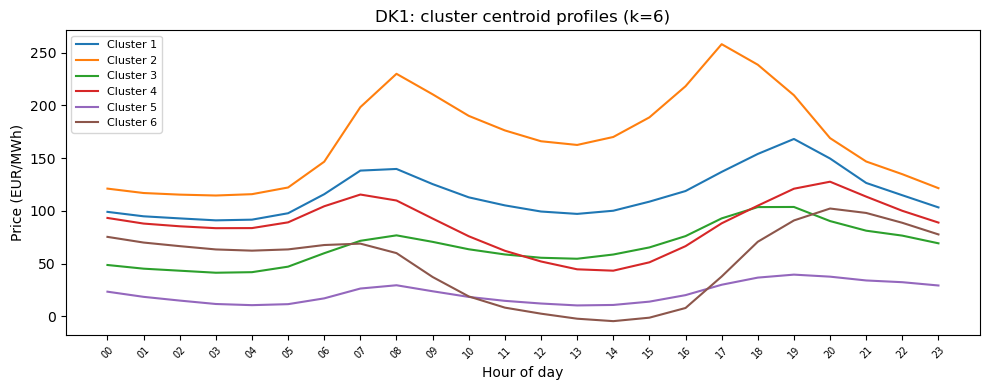

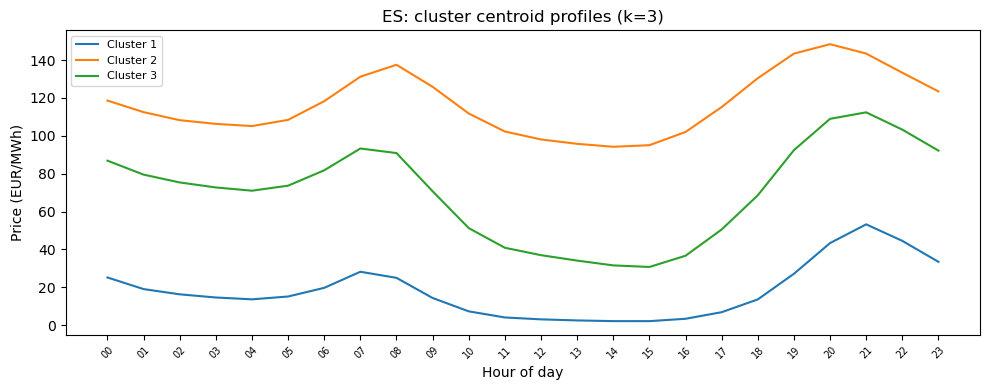

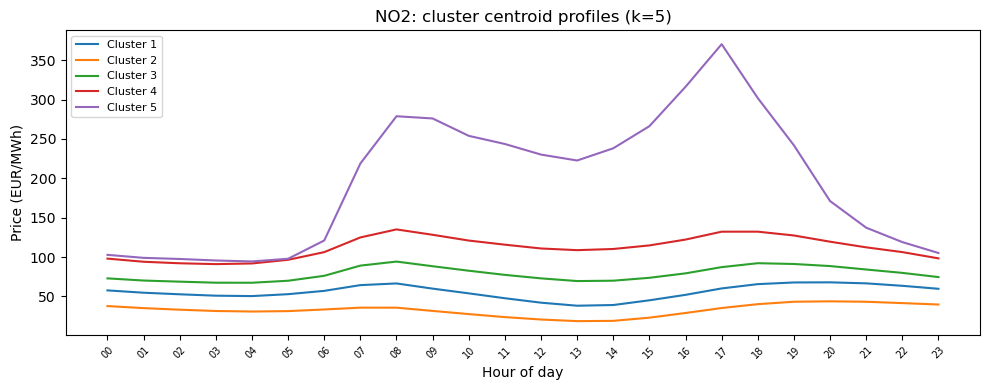

In [12]:
# 3-C · Cluster centroid profiles (mean 24h price per cluster)
for zone, cfg in ZONES.items():
    if zone not in clusters_dfs:
        continue
    k = cfg['k_focus']
    price_path = CLEAN_DIR / f'{zone}_preprocessed.csv'
    if not price_path.exists():
        print(f'{zone}: price CSV missing - skipping centroid plot.')
        continue

    df_prices = pd.read_csv(price_path)
    df_prices['date'] = pd.to_datetime(df_prices['date']).dt.normalize()

    df_cl = clusters_dfs[zone].copy()
    df_cl['date'] = pd.to_datetime(df_cl['date']).dt.normalize()

    merged = df_prices.merge(df_cl[['date', 'cluster']], on='date', how='inner')
    h_cols = [f'h{i:02d}' for i in range(24)]
    X = merged[h_cols].to_numpy(dtype=float)
    labels = merged['cluster'].to_numpy()

    cluster_ids_sorted = sorted(merged['cluster'].unique())
    centroids = np.array([X[labels == c].mean(axis=0) for c in cluster_ids_sorted])
    centroids_df = pd.DataFrame(centroids, index=cluster_ids_sorted, columns=h_cols)
    plot_cluster_centroids(centroids_df, k, zone)


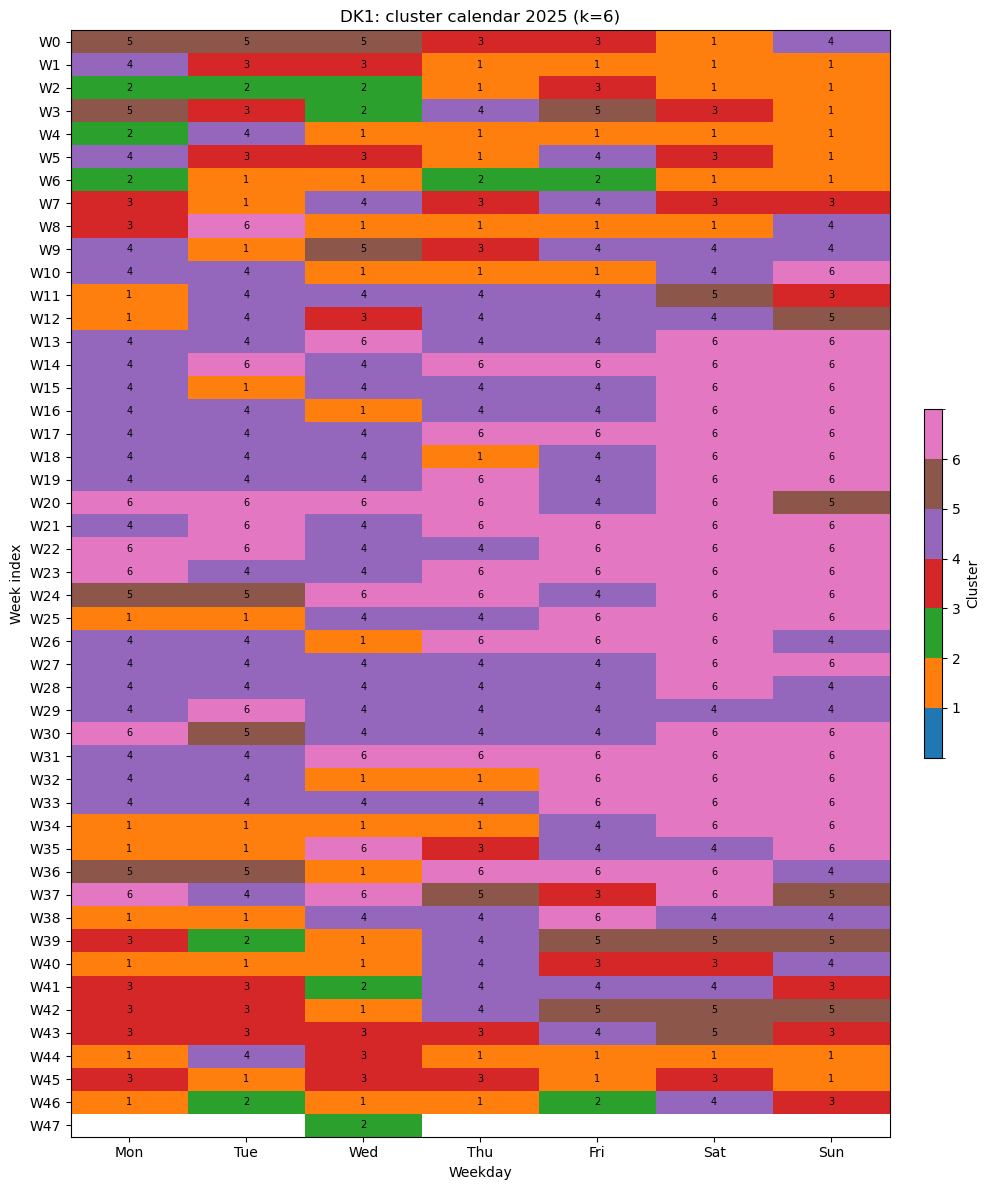

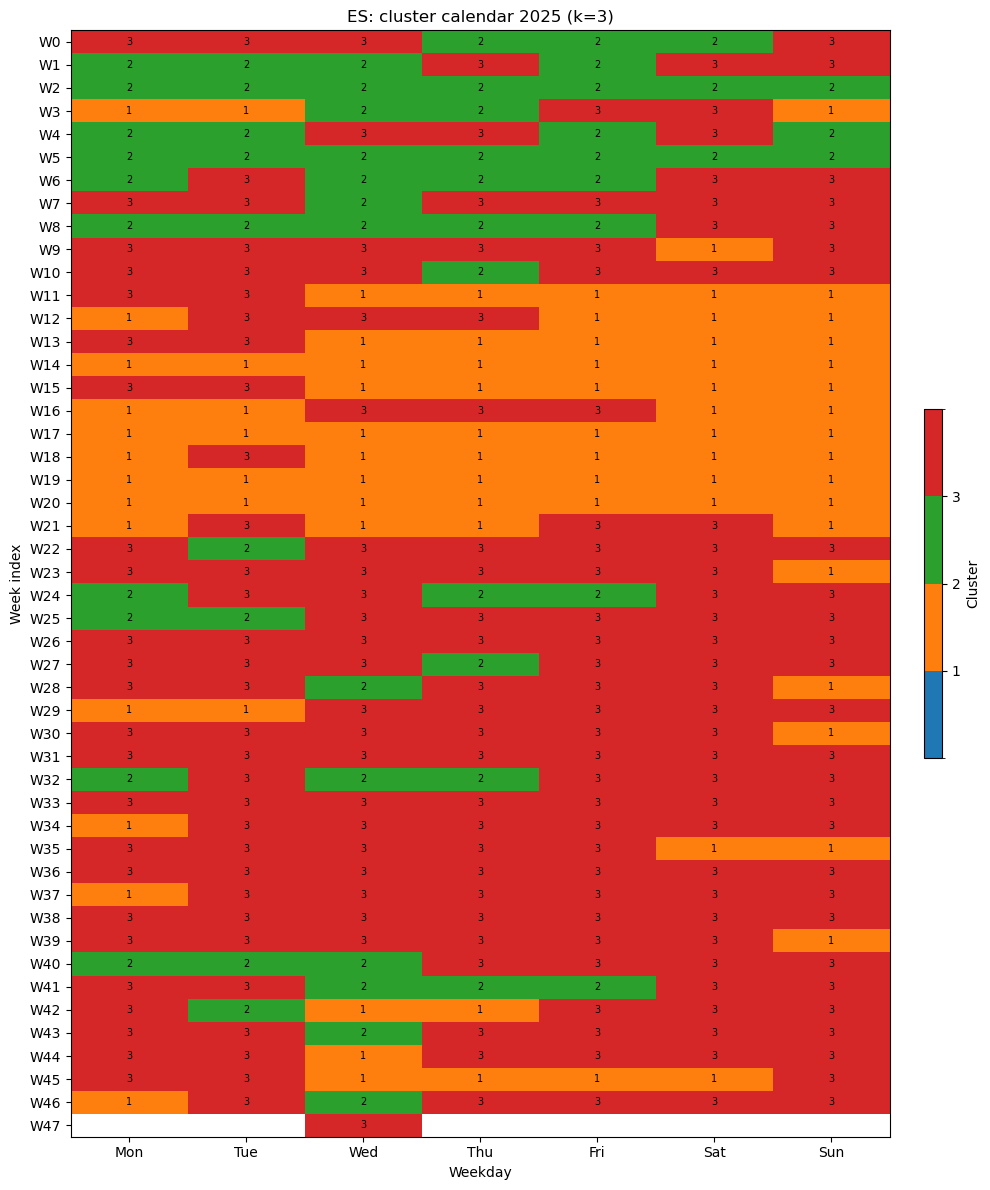

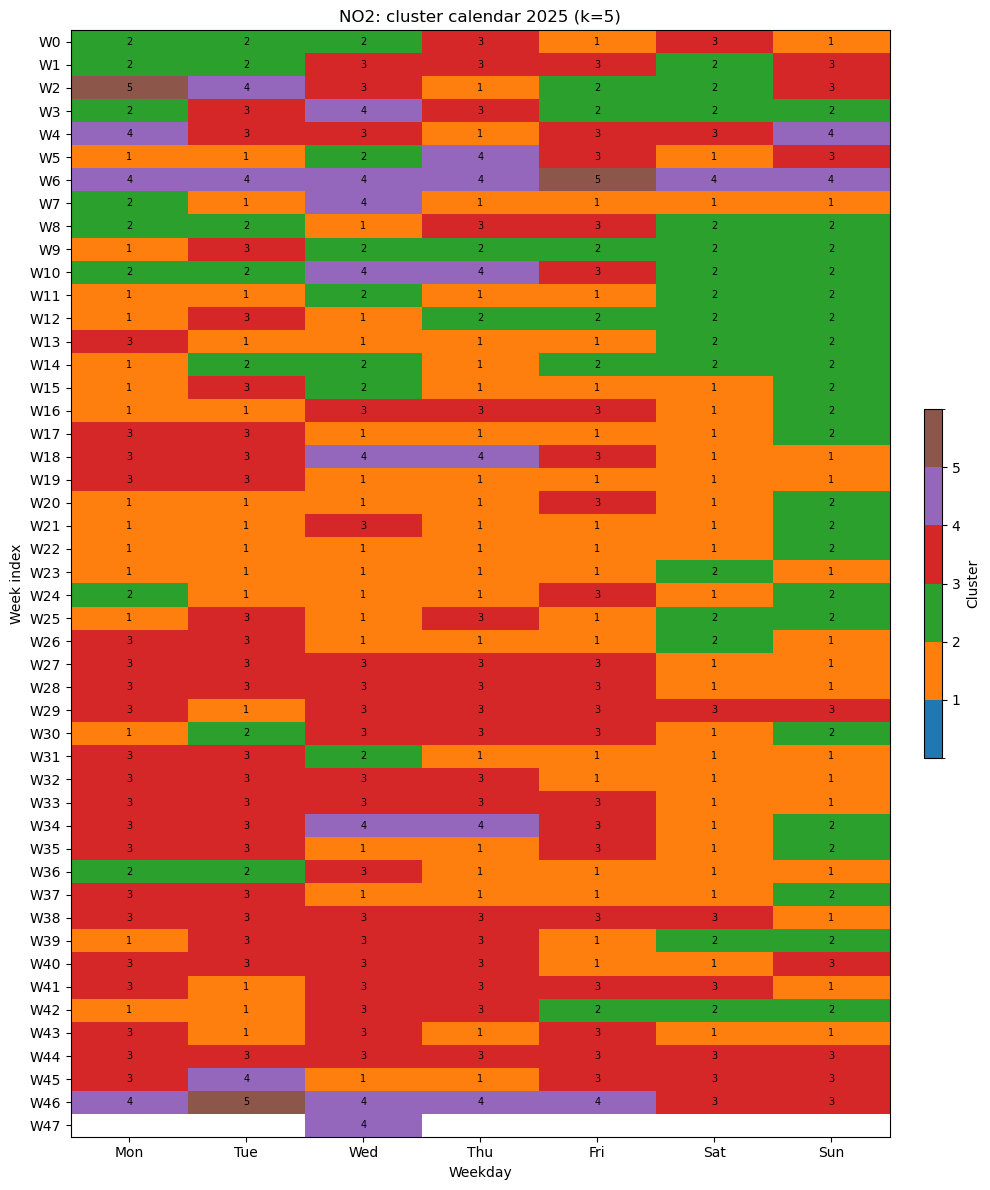

In [13]:
# 3-D · Cluster calendar heatmap - most recent available year per zone
for zone, cfg in ZONES.items():
    if zone not in clusters_dfs:
        continue
    k = cfg['k_focus']
    df_cl = clusters_dfs[zone].copy()
    df_cl['date'] = pd.to_datetime(df_cl['date'])

    latest_year = int(df_cl['date'].dt.year.max())
    df_year = df_cl[df_cl['date'].dt.year == latest_year].copy()
    df_year['weekday']    = df_year['date'].dt.weekday
    # 0-based week index from the start of the year
    year_start = pd.Timestamp(f'{latest_year}-01-01')
    df_year['week_index'] = ((df_year['date'] - year_start).dt.days // 7).astype(int)

    unique_clusters = sorted(df_year['cluster'].unique())
    n_cl   = len(unique_clusters)
    colours = plt.get_cmap('tab10').colors
    cmap   = mcolors.ListedColormap([colours[i % len(colours)] for i in range(n_cl + 1)])
    bounds = list(range(n_cl + 2))
    norm   = mcolors.BoundaryNorm(bounds, cmap.N)

    plot_cluster_calendar_for_year(df_year, latest_year, 'cluster', cmap, norm, k, zone)


---
## 4 · Model Training

**Layer 1** - XGBoost multi-class classifier: daily features → cluster probabilities.  
**Layer 2** - One XGBoost regressor per cluster: hourly weather + rolling precip → price.  
**Naive baselines** - Naive-1 (yesterday's price) and Naive-2 (weather-only XGBoost).

All training cells are guarded - they skip if the model bundle already exists on disk.


In [14]:
# 4-A · Layer 1 feature construction (daily aggregation + lags + dummies + cluster)
layer1_data = {}

for zone in ZONES:
    if zone not in masterset_dfs or zone not in clusters_dfs:
        print(f'{zone}: missing masterset or clusters - skipping Layer 1 features.')
        continue

    df_ms    = masterset_dfs[zone].copy()
    df_daily = make_daily_values(df_ms)           # hourly → daily averages
    df_lag   = make_cluster_pred(df_daily)         # add price lags 1/2/3; drop avg_price
    df_we    = add_weekend_dummy(df_lag)           # is_weekend binary
    df_seas  = add_season_dummies(df_we)           # season_spring/summer/autumn
    df_feat  = attach_cluster(df_seas, clusters_dfs[zone])  # join cluster label

    print(f'{zone}: Layer 1 features  shape={df_feat.shape}  '
          f'clusters={sorted(df_feat["cluster"].unique())}')
    layer1_data[zone] = df_feat


DK1: Layer 1 features  shape=(1058, 13)  clusters=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
ES: Layer 1 features  shape=(1058, 13)  clusters=[np.int64(1), np.int64(2), np.int64(3)]
NO2: Layer 1 features  shape=(1058, 13)  clusters=[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [15]:
# 4-B · Train Layer 1 cluster classifiers (guarded per zone)
for zone in ZONES:
    if zone not in layer1_data:
        continue
    short      = ZONE_SHORT_CODE[zone]
    model_path = MODELS_DIR / f'xgb_cluster_{short}.joblib'

    if not model_path.exists():
        print(f'\nTraining Layer 1 classifier for {zone}...')
        model, feature_cols, le, splits, report = train_xgb_classifier(
            layer1_data[zone], name=short, out_dir=MODELS_DIR
        )
        save_cluster_model_bundle(model, feature_cols, le, model_path)
    else:
        print(f'{zone}: Layer 1 bundle already on disk → {model_path.name}')


DK1: Layer 1 bundle already on disk → xgb_cluster_DK.joblib
ES: Layer 1 bundle already on disk → xgb_cluster_ES.joblib
NO2: Layer 1 bundle already on disk → xgb_cluster_NO.joblib


In [16]:
# 4-C · Train Layer 2 per-cluster regressors (guarded per model file)
# Uses best_p rolling precipitation window per zone (from ZONES config).
L2_MODELS_DIR = MODELS_DIR / 'within_cluster'
L2_MODELS_DIR.mkdir(parents=True, exist_ok=True)

l2_meta = {}  # {zone: {'cluster_ids': [...], 'model_files': [...]}}

for zone, cfg in ZONES.items():
    if zone not in masterset_dfs or zone not in clusters_dfs:
        continue
    short = ZONE_SHORT_CODE[zone]
    p     = cfg['best_p']

    # Build hourly feature DataFrame with rolling precipitation
    df_h = masterset_dfs[zone].copy()
    df_h['date'] = pd.to_datetime(df_h['date_time'], utc=True).dt.normalize().dt.strftime('%Y-%m-%d')
    df_h = add_precipitation_last_x_days(df_h, p)
    df_h = attach_cluster(df_h, clusters_dfs[zone])

    cluster_ids = sorted(df_h['cluster'].unique())
    model_files = []

    for c in cluster_ids:
        model_name = f'xgb_price_{short}_p{p}_c{c}'
        model_file = f'{model_name}.joblib'
        model_path = L2_MODELS_DIR / model_file

        if not model_path.exists():
            df_c = df_h[df_h['cluster'] == c].copy()
            drop = [col for col in ['date_time', 'date', 'cluster'] if col in df_c.columns]
            df_c = df_c.drop(columns=drop).dropna()
            if len(df_c) < 100:
                print(f'  {zone} cluster {c}: only {len(df_c)} rows - skipping.')
                continue
            print(f'\nTraining Layer 2 for {zone} cluster {c}  (n={len(df_c)})...')
            xgb_price_within_cluster(df_c, model_name, model_dir=L2_MODELS_DIR)
        else:
            print(f'{zone} cluster {c}: Layer 2 model on disk → {model_file}')

        model_files.append(model_file)

    l2_meta[zone] = {'cluster_ids': cluster_ids, 'model_files': model_files}


DK1 cluster 1: Layer 2 model on disk → xgb_price_DK_p20_c1.joblib
DK1 cluster 2: Layer 2 model on disk → xgb_price_DK_p20_c2.joblib
DK1 cluster 3: Layer 2 model on disk → xgb_price_DK_p20_c3.joblib
DK1 cluster 4: Layer 2 model on disk → xgb_price_DK_p20_c4.joblib
DK1 cluster 5: Layer 2 model on disk → xgb_price_DK_p20_c5.joblib
DK1 cluster 6: Layer 2 model on disk → xgb_price_DK_p20_c6.joblib
ES cluster 1: Layer 2 model on disk → xgb_price_ES_p20_c1.joblib
ES cluster 2: Layer 2 model on disk → xgb_price_ES_p20_c2.joblib
ES cluster 3: Layer 2 model on disk → xgb_price_ES_p20_c3.joblib
NO2 cluster 1: Layer 2 model on disk → xgb_price_NO_p7_c1.joblib
NO2 cluster 2: Layer 2 model on disk → xgb_price_NO_p7_c2.joblib
NO2 cluster 3: Layer 2 model on disk → xgb_price_NO_p7_c3.joblib
NO2 cluster 4: Layer 2 model on disk → xgb_price_NO_p7_c4.joblib
NO2 cluster 5: Layer 2 model on disk → xgb_price_NO_p7_c5.joblib


In [17]:
# 4-D · Train Naive-2 baseline (single weather-only XGBRegressor, no clustering)
NAIVE2_DIR = MODELS_DIR / 'naive_two'
NAIVE2_DIR.mkdir(parents=True, exist_ok=True)

for zone, cfg in ZONES.items():
    if zone not in masterset_dfs:
        continue
    short      = ZONE_SHORT_CODE[zone]
    p          = cfg['best_p']
    model_name = f'naive_two_{short.lower()}'
    model_path = NAIVE2_DIR / f'{model_name}.joblib'

    if not model_path.exists():
        print(f'\nTraining Naive-2 baseline for {zone}...')
        df_h = masterset_dfs[zone].copy()
        df_h['date'] = pd.to_datetime(df_h['date_time'], utc=True).dt.normalize().dt.strftime('%Y-%m-%d')
        df_h = add_precipitation_last_x_days(df_h, p)

        drop = [col for col in ['date_time', 'date', 'cluster'] if col in df_h.columns]
        df_train = df_h.drop(columns=drop).dropna()
        train_naive_weather_model(df_train, model_name, label=zone, model_dir=NAIVE2_DIR)
    else:
        print(f'{zone}: Naive-2 model on disk → {model_path.name}')


DK1: Naive-2 model on disk → naive_two_dk.joblib
ES: Naive-2 model on disk → naive_two_es.joblib
NO2: Naive-2 model on disk → naive_two_no.joblib


In [18]:
# 4-E · Naive-1: no training required - yesterday's price at the same hour.
# Computed at evaluation time using naive_approach_one().
print('Naive-1 baseline: no training needed (shift prices by 24h at prediction time).')


Naive-1 baseline: no training needed (shift prices by 24h at prediction time).


---
## 5 · Evaluation & Results

Generate predictions from all three approaches and report MAE, sMAPE, and WAPE.


In [19]:
# 5-A · Generate predictions for all zones and all approaches
results     = {}   # {zone: {approach_label: (mae, smape, wape)}}
pred_dfs    = {}   # store cluster-model prediction DataFrames for plotting

for zone, cfg in ZONES.items():
    if zone not in masterset_dfs:
        print(f'{zone}: masterset missing - skipping evaluation.')
        continue

    short = ZONE_SHORT_CODE[zone]
    p     = cfg['best_p']
    results[zone] = {}

    # ── Shared hourly DataFrame with rolling precipitation ────────────
    df_h = masterset_dfs[zone].copy()
    df_h['date'] = pd.to_datetime(df_h['date_time'], utc=True).dt.normalize().dt.strftime('%Y-%m-%d')
    df_h = add_precipitation_last_x_days(df_h, p)

    # ── Filter to test set only - matching original notebook cutoff dates ─
    cutoff  = cfg['eval_cutoff']
    df_eval = df_h[pd.to_datetime(df_h['date']) >= cutoff].copy()

    # ── Naive-1: yesterday's price ────────────────────────────────────
    df_n1 = naive_approach_one(df_eval, dt_col='date_time', price_col='price_eur_mwh')
    df_n1 = df_n1.dropna(subset=['naive_one_pred_price', 'price_eur_mwh'])
    mae, smape, wape = avg_errors(
        df_n1, pred_col='naive_one_pred_price', actual_col='price_eur_mwh'
    )
    results[zone]['Naive-1 (yesterday)'] = (mae, smape, wape)
    print(f'{zone}  Naive-1   WAPE={wape:.2f}%')

    # ── Naive-2: weather-only XGBoost ────────────────────────────────
    n2_path = NAIVE2_DIR / f'naive_two_{short.lower()}.joblib'
    if n2_path.exists():
        n2_bundle = joblib.load(n2_path)
        n2_fcols  = n2_bundle['feature_cols']
        n2_model  = n2_bundle['model']
        df_n2     = df_eval.dropna(subset=n2_fcols + ['price_eur_mwh'])
        print(df_eval.head())
        n2_pred   = n2_model.predict(df_n2[n2_fcols])
        df_n2     = df_n2.assign(naive_two_pred=n2_pred)
        mae, smape, wape = avg_errors(
            df_n2, pred_col='naive_two_pred', actual_col='price_eur_mwh'
        )
        results[zone]['Naive-2 (weather)'] = (mae, smape, wape)
        print(f'{zone}  Naive-2   WAPE={wape:.2f}%')
    else:
        print(f'{zone}  Naive-2   model not found - skipping.')

    # ── Cluster model: Layer 1 probabilities + Layer 2 weighted sum ───
    l1_path = MODELS_DIR / f'xgb_cluster_{short}.joblib'
    meta    = l2_meta.get(zone, {})
    c_ids   = meta.get('cluster_ids', [])
    m_files = meta.get('model_files', [])

    l1_ok = l1_path.exists()
    l2_ok = all((L2_MODELS_DIR / f).exists() for f in m_files) and len(m_files) > 0

    if l1_ok and l2_ok and zone in layer1_data:
        proba_df = predict_cluster_probabilities(l1_path, layer1_data[zone], date_col='date')
        pred_df  = weighted_price_prediction(
            test_df     = df_eval,
            proba_df    = proba_df,
            model_files = m_files,
            cluster_ids = c_ids,
            models_dir  = L2_MODELS_DIR,
            date_col    = 'date',
        )
        pred_df  = pred_df.dropna(subset=['weighted_pred_price', 'price_eur_mwh'])
        mae, smape, wape = avg_errors(
            pred_df, pred_col='weighted_pred_price', actual_col='price_eur_mwh'
        )
        results[zone]['Cluster Model'] = (mae, smape, wape)
        pred_dfs[zone] = pred_df
        print(f'{zone}  Cluster   WAPE={wape:.2f}%')
    else:
        print(f'{zone}  Cluster   models not ready - skipping.')

    print()

DK1  Naive-1   WAPE=34.65%
                       date_time  price_eur_mwh  temperature_2m  \
21572  2025-06-18 00:00:00+00:00         101.50       14.086578   
21573  2025-06-18 01:00:00+00:00          95.84       13.811645   
21574  2025-06-18 02:00:00+00:00          97.01       13.666626   
21575  2025-06-18 03:00:00+00:00          94.12       13.608154   
21576  2025-06-18 04:00:00+00:00         112.35       13.575806   

       wind_speed_10m  precipitation_mm  solar_radiation_W       date  \
21572        6.874238          0.002690           0.000000 2025-06-18   
21573        6.817234          0.001620           0.000000 2025-06-18   
21574        7.039088          0.001703           0.000000 2025-06-18   
21575        6.978535          0.001409           2.122507 2025-06-18   
21576        6.727240          0.001418          41.013447 2025-06-18   

       precipitation_last_20_days  
21572                    46.28065  
21573                    46.28065  
21574                  

In [20]:
# 5-B · Results table - all zones × all approaches × MAE / sMAPE% / WAPE%
if results:
    df_results = build_results_table(results)
    print(df_results.to_string(index=False))
else:
    print('No results to display - run Section 5-A first.')


Zone            Approach  MAE (EUR/MWh)    sMAPE%     WAPE%
 DK1 Naive-1 (yesterday)      27.392011 57.700406 34.649514
 DK1   Naive-2 (weather)      26.361396 50.647301 33.385899
 DK1       Cluster Model      24.752700 49.246322 31.348536
  ES Naive-1 (yesterday)      20.223196 59.199557 29.887795
  ES   Naive-2 (weather)      27.305585 57.326440 40.183005
  ES       Cluster Model      23.122575 54.251351 34.027271
 NO2 Naive-1 (yesterday)      15.072461 34.041305 22.469078
 NO2   Naive-2 (weather)      19.621072 37.021335 29.249355
 NO2       Cluster Model      15.868400 32.382728 23.655204


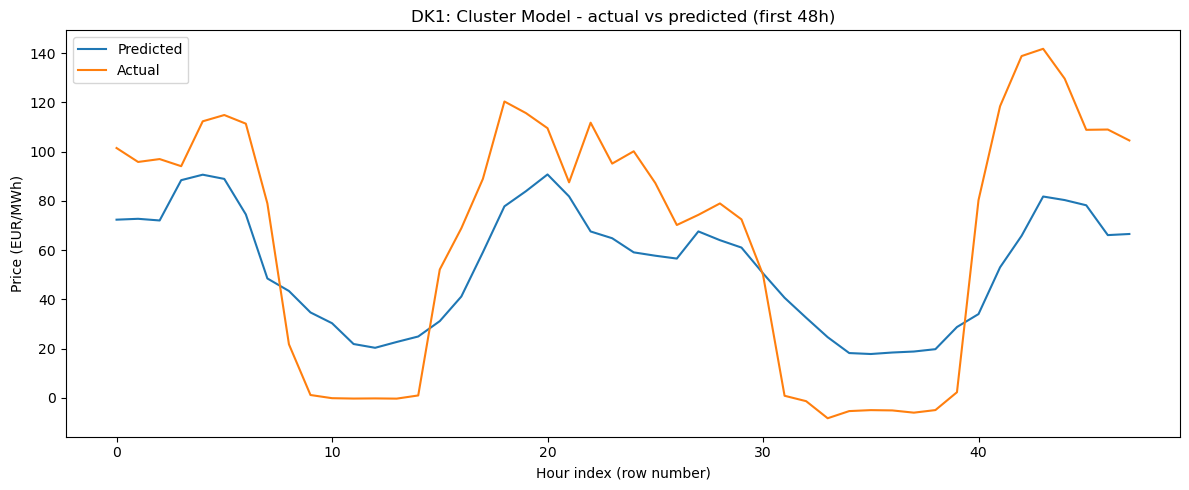

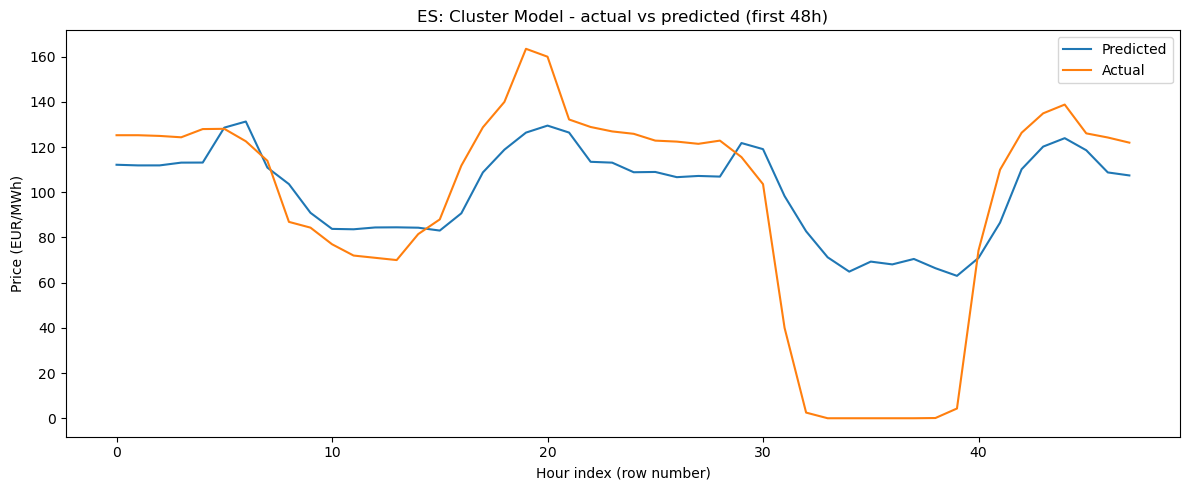

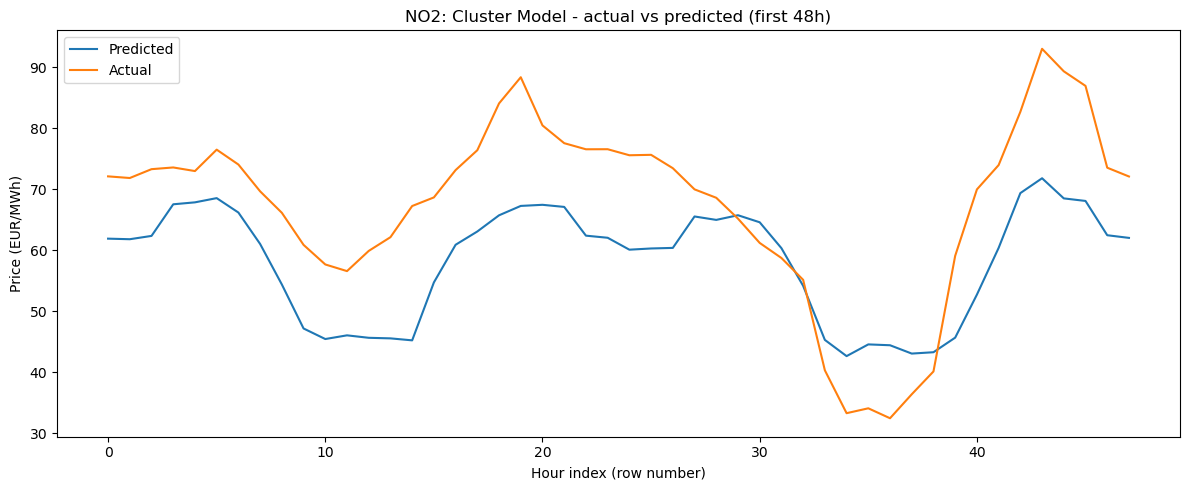

In [21]:
# 5-C · Actual vs predicted - first 48h of cluster-model output per zone
for zone, pred_df in pred_dfs.items():
    plot_hourly_series(
        pred_df,
        title=f'{zone}: Cluster Model - actual vs predicted (first 48h)',
        pred_col='weighted_pred_price',
        actual_col='price_eur_mwh',
        n_hours=48,
        
    )


---
## 6 · Sanity Checks

Automated assertions that catch common failures. All checks print `[OK]` when passing.


In [22]:
# 6-A · Cluster size assertions + WAPE sanity checks
MIN_CLUSTER_DAYS = 60
any_warning = False

# Check 1: cluster sizes
for zone, df_cl in clusters_dfs.items():
    sizes = df_cl['cluster'].value_counts()
    small = sizes[sizes < MIN_CLUSTER_DAYS]
    if not small.empty:
        print(f'WARNING [{zone}]: clusters {small.index.tolist()} have < {MIN_CLUSTER_DAYS} days')
        any_warning = True
    else:
        print(f'[OK] {zone}: all clusters >= {MIN_CLUSTER_DAYS} days')

# Check 2: WAPE values in [0, 100]
for zone, approaches in results.items():
    for approach, (mae, smape, wape) in approaches.items():
        if not (0 < wape < 100):
            print(f'WARNING [{zone}] {approach}: WAPE={wape:.2f}% is outside (0, 100)')
            any_warning = True
        else:
            print(f'[OK] {zone} {approach}: WAPE={wape:.2f}%')

# Check 3: perfect-prediction sanity (WAPE of actuals against themselves should be 0)
for zone, df_ms in list(masterset_dfs.items())[:1]:
    actuals = df_ms['price_eur_mwh'].dropna().to_numpy()
    _, _, wape_zero = mae_smape_wape(actuals, actuals)
    assert wape_zero == 0.0, f'Self-prediction WAPE should be 0, got {wape_zero}'
    print(f'[OK] Self-prediction WAPE == 0.0 ({zone})')

if not any_warning:
    print('\nAll checks passed.')


WARNING [DK1]: clusters [2] have < 60 days
[OK] ES: all clusters >= 60 days
WARNING [NO2]: clusters [5] have < 60 days
[OK] DK1 Naive-1 (yesterday): WAPE=34.65%
[OK] DK1 Naive-2 (weather): WAPE=33.39%
[OK] DK1 Cluster Model: WAPE=31.35%
[OK] ES Naive-1 (yesterday): WAPE=29.89%
[OK] ES Naive-2 (weather): WAPE=40.18%
[OK] ES Cluster Model: WAPE=34.03%
[OK] NO2 Naive-1 (yesterday): WAPE=22.47%
[OK] NO2 Naive-2 (weather): WAPE=29.25%
[OK] NO2 Cluster Model: WAPE=23.66%
[OK] Self-prediction WAPE == 0.0 (DK1)


In [23]:
# 6-B · Hourly coverage check - fraction of hours with all features present
print(f'{"Zone":<6}  {"Total hrs":>10}  {"NaN price":>10}  {"Coverage%":>10}')
print('-' * 45)
for zone, df in masterset_dfs.items():
    total  = len(df)
    n_nan  = int(df['price_eur_mwh'].isna().sum())
    pct    = (total - n_nan) / total * 100
    print(f'{zone:<6}  {total:>10,}  {n_nan:>10,}  {pct:>9.2f}%')

    # Warn if any weather column has NaN
    weather_cols = ['temperature_2m', 'wind_speed_10m', 'precipitation_mm', 'solar_radiation_W']
    for col in weather_cols:
        if col in df.columns:
            n_w = int(df[col].isna().sum())
            if n_w > 0:
                print(f'  WARNING: {zone}.{col} has {n_w} NaN rows')


Zone     Total hrs   NaN price   Coverage%
---------------------------------------------
DK1         25,457           0     100.00%
ES          25,457           0     100.00%
NO2         25,457           0     100.00%


## Model Failure diagnostics

---
## 7 · Part 1 Diagnostics - Fixed Metrics & Full Breakdown

**Run this section after Section 5 (Evaluation & Results).**
Requires `pred_dfs` and `clusters_dfs` to already be in memory.

What this section does:
1. Imports the three diagnostic functions from `diagnostics_part1.py`
2. Runs all breakdowns (cluster / season / day-type / price-bucket) for each zone
3. Prints formatted tables with MAE, raw WAPE, clamped WAPE, and signed bias

**Clamped WAPE**

Standard WAPE divides by $\sum |y|$. When actual prices are near zero or negative, this denominator collapses and WAPE inflates arbitrarily - not because the model is bad, but because the metric breaks down.

Clamped WAPE fixes this by enforcing a minimum absolute price $\delta$ in the denominator:

$$\text{WAPE}_{\text{CL}} = \frac{\sum |y_{pred} - y_{true}|}{\sum \max(|y_{true}|,\ \delta)} \times 100$$

where $\delta = 10$ EUR/MWh by default. For any hour where $|y_{true}| < \delta$, the denominator uses $\delta$ instead. The numerator is unchanged.

The gap between raw WAPE and $\text{WAPE}_{\text{CL}}$ in any slice is the inflation caused by the denominator problem - not by model error.






4. Produces one four-panel figure per zone saved as `diagnostic_{zone}.png`
5. Prints a cross-zone comparison table at the end


In [24]:
# ── 7-A  Import diagnostic module ────────────────────────────────────────────
#
# Adjust the import path to match where you saved the file.

import importlib.util, sys
from pathlib import Path


# load from src/ ---
_diag_path = ROOT / 'src' / 'diagnostics_part1.py'

spec   = importlib.util.spec_from_file_location('diagnostics_part1', _diag_path)
diag   = importlib.util.module_from_spec(spec)
spec.loader.exec_module(diag)

print(f'Loaded diagnostics from: {_diag_path}')
print('Functions available:', [f for f in dir(diag) if not f.startswith('_')])

Loaded diagnostics from: D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\src\diagnostics_part1.py
Functions available: ['BUCKET_ORDER', 'COLORS', 'Patch', 'assign_price_bucket', 'cross_zone_comparison', 'diagnostic_metrics', 'gridspec', 'np', 'pd', 'plt', 'run_all_zones', 'run_full_diagnostic']


In [25]:
# ── 7-B  Quick sanity check on the new metric function ───────────────────────
# Verify that clamped WAPE and standard WAPE differ on near-zero prices,
# and that bias is correctly signed.

import numpy as np

# Case 1: normal prices - both WAPEs should be close
y_true_normal = np.array([50.0, 80.0, 60.0, 70.0])
y_pred_normal = np.array([55.0, 75.0, 65.0, 68.0])
m_normal = diag.diagnostic_metrics(y_true_normal, y_pred_normal, price_floor=10)
print('Normal prices:')
print(f'  MAE={m_normal["mae"]:.2f}  WAPE={m_normal["wape"]:.2f}%  '
      f'WAPE_CL={m_normal["wape_cl"]:.2f}%  BIAS={m_normal["bias"]:+.2f}')

# Case 2: near-zero prices - raw WAPE should explode, clamped should stay sane
y_true_zero = np.array([0.5, -1.0, 1.5, 2.0])
y_pred_zero = np.array([5.0,  5.0, 5.0, 5.0])
m_zero = diag.diagnostic_metrics(y_true_zero, y_pred_zero, price_floor=10)
print('\nNear-zero prices:')
print(f'  MAE={m_zero["mae"]:.2f}  WAPE={m_zero["wape"]:.2f}%  '
      f'WAPE_CL={m_zero["wape_cl"]:.2f}%  BIAS={m_zero["bias"]:+.2f}')
print('  ↑ Raw WAPE should be much larger than clamped WAPE here.')

# Case 3: systematic under-prediction - bias should be negative
y_true_spike = np.array([200.0, 250.0, 300.0])
y_pred_spike = np.array([150.0, 180.0, 220.0])
m_spike = diag.diagnostic_metrics(y_true_spike, y_pred_spike, price_floor=10)
print('\nSpike prices (under-predicted):')
print(f'  MAE={m_spike["mae"]:.2f}  WAPE={m_spike["wape"]:.2f}%  '
      f'WAPE_CL={m_spike["wape_cl"]:.2f}%  BIAS={m_spike["bias"]:+.2f}')
print('  ↑ Bias should be negative (model under-predicts).')

Normal prices:
  MAE=4.25  WAPE=6.54%  WAPE_CL=6.54%  BIAS=+0.75

Near-zero prices:
  MAE=4.25  WAPE=340.00%  WAPE_CL=42.50%  BIAS=+4.25
  ↑ Raw WAPE should be much larger than clamped WAPE here.

Spike prices (under-predicted):
  MAE=66.67  WAPE=26.67%  WAPE_CL=26.67%  BIAS=-66.67
  ↑ Bias should be negative (model under-predicts).



▶▶▶  Running diagnostics for DK1  ◀◀◀

  DIAGNOSTIC SUMMARY - DK1   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,885  100.0%    24.75   31.35%    30.94%    +0.31

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  Cluster 5              

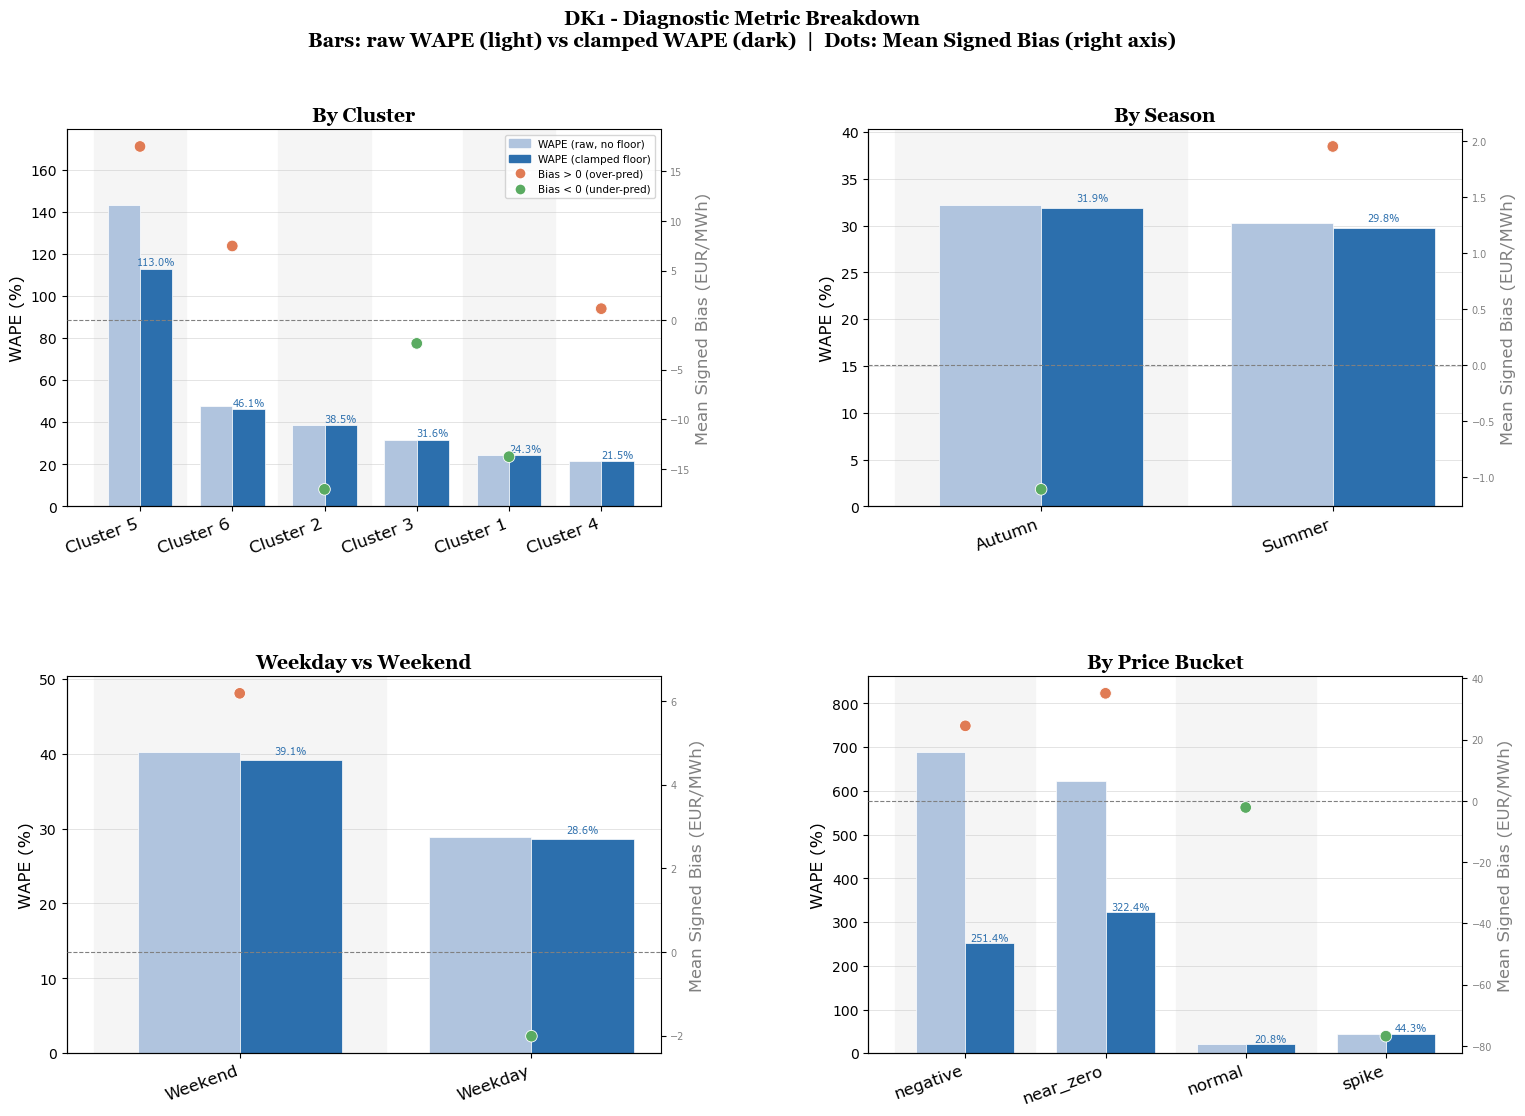

  Figure saved → diagnostic_DK1.png

▶▶▶  Running diagnostics for ES  ◀◀◀

  DIAGNOSTIC SUMMARY - ES   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,837  100.0%    23.12   34.03%    33.41%   +10.03

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────

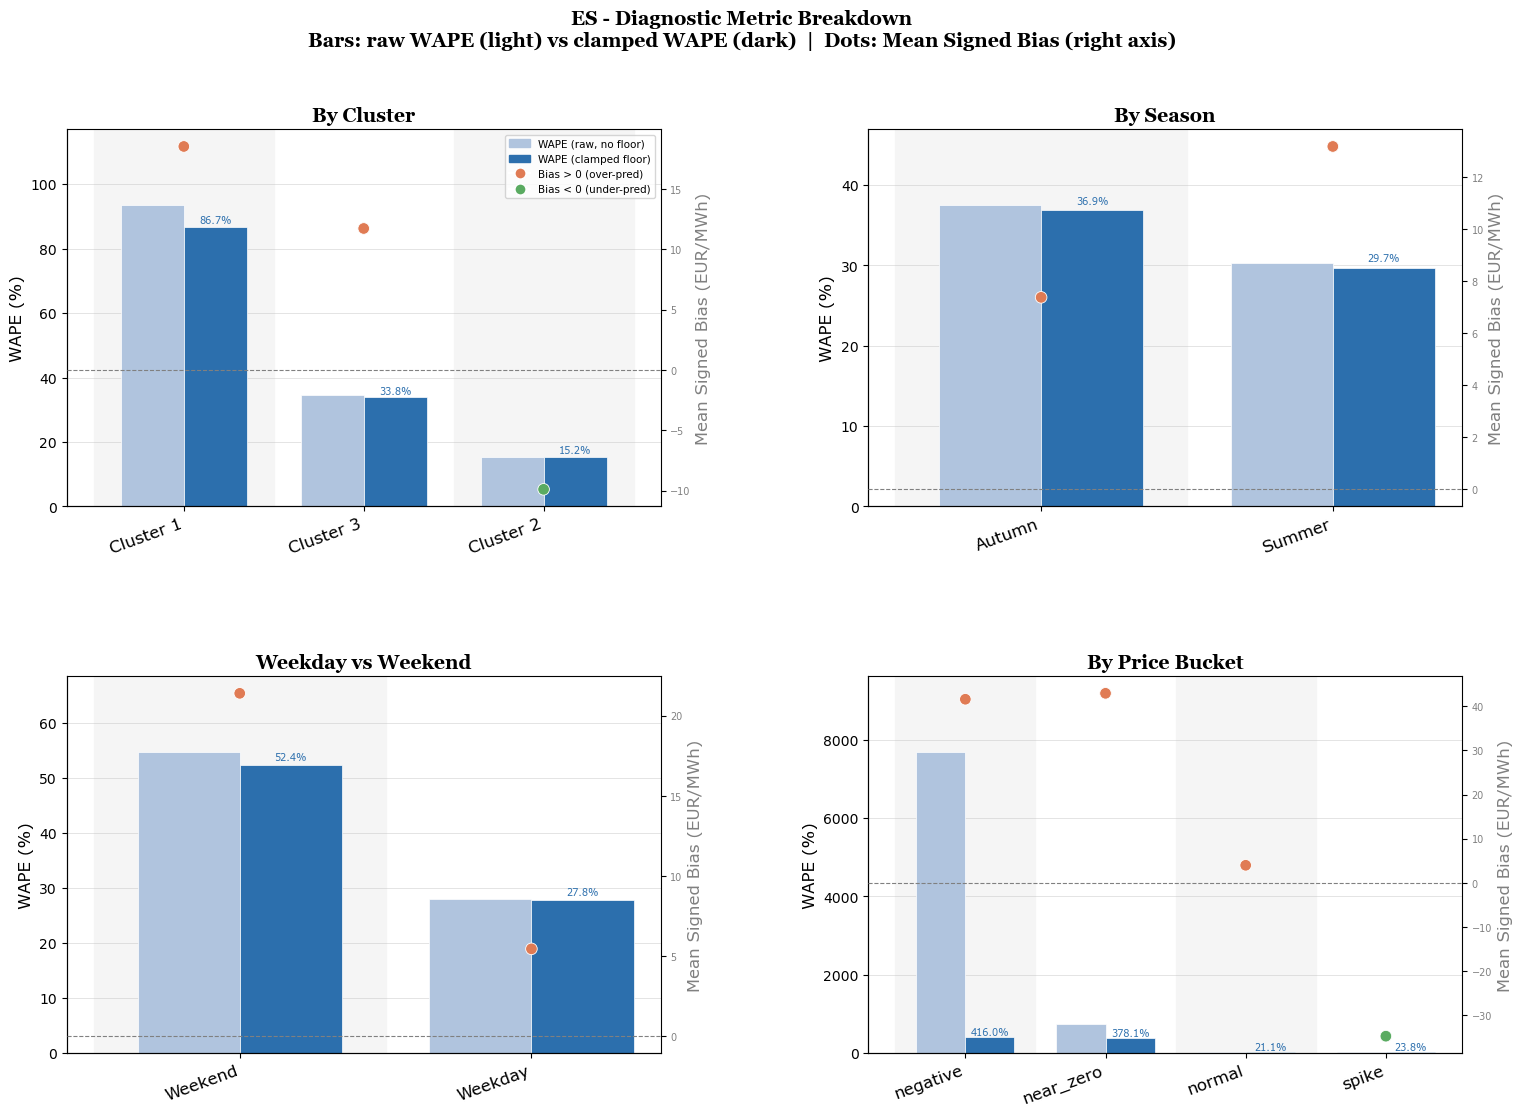

  Figure saved → diagnostic_ES.png

▶▶▶  Running diagnostics for NO2  ◀◀◀

  DIAGNOSTIC SUMMARY - NO2   (price_floor = 10.0 EUR/MWh)

  ──────────────────────────────────────────────────────────────────────────
  Overall
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ──────────────────────────────────────────────────────────────────────────
  All                      3,837  100.0%    15.87   23.66%    23.52%    -3.63

  ──────────────────────────────────────────────────────────────────────────
  By Cluster
  ──────────────────────────────────────────────────────────────────────────
  Group                    N hrs  % test      MAE     WAPE   WAPE_CL     BIAS
                                          EUR/MWh        %   % (fld)  EUR/MWh
  ─────────────────────────────────────────────────────────────────

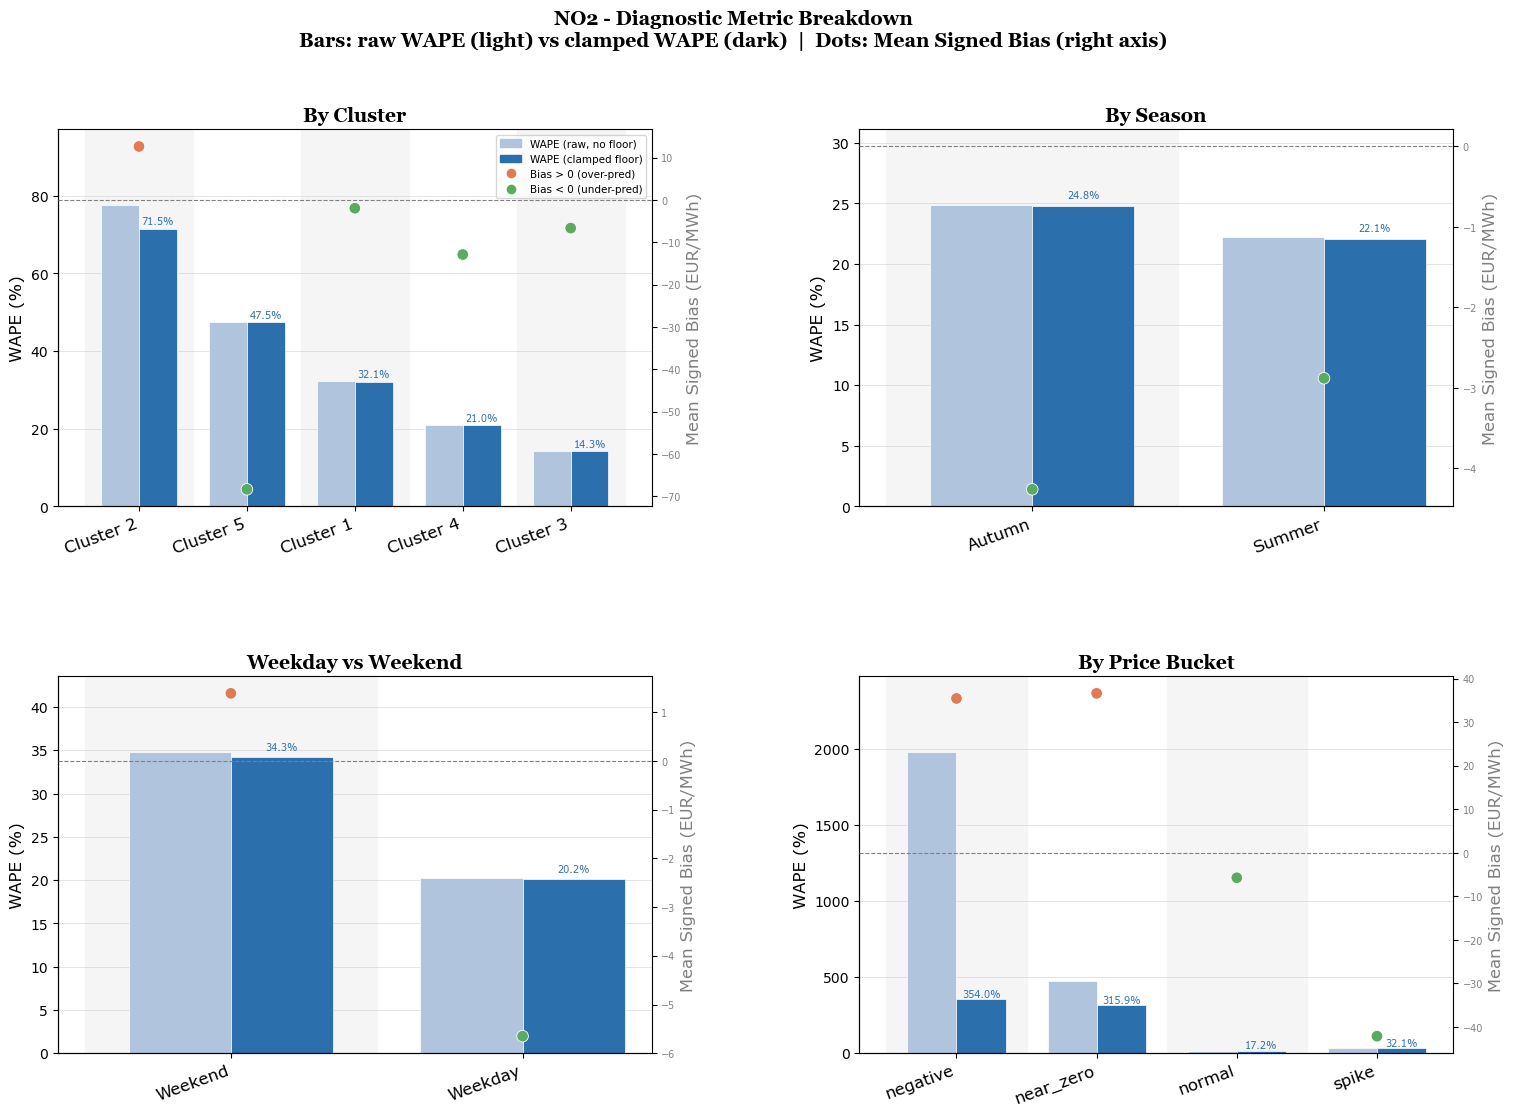

  Figure saved → diagnostic_NO2.png


In [26]:
# ── 7-C  Run full diagnostics across all zones ───────────────────────────────
#
# pred_dfs and clusters_dfs are already in memory from Sections 3 and 5.
# This cell produces:
#   - a formatted breakdown table printed to stdout for each zone
#   - a four-panel figure saved as diagnostic_{zone}.png
#   - summaries dict for further inspection

PRICE_FLOOR = 10.0   # EUR/MWh - change if you want a different threshold

summaries = diag.run_all_zones(
    pred_dfs     = pred_dfs,
    clusters_dfs = clusters_dfs,
    price_floor  = PRICE_FLOOR,
)

## Diagnostic Results - Part 1

### Breakdown by Cluster

The worst-performing cluster differs by zone: Cluster 2 in DK1, Cluster 1 in ES, and Cluster 2 in NO2 each record the highest clamped WAPE within their respective zones. **CHECK IF TRUEAll three will be inspected in detail in the subsequent diagnostic steps, where we decompose whether the error originates in Layer 1 misclassification or Layer 2 regression weakness.**

### Seasonal Breakdown

Across all three bidding zones, the seasonal breakdown does not surface meaningful differences. Summer and autumn WAPE figures are closely aligned in DK1, ES, and NO2, suggesting that the model's weaknesses are not concentrated in a particular time of year and are instead structural rather than seasonal. Moreover, the test set comprises only from the second half of the year, making the analysis redundant as it does not show two out of four seasons.

### Breakdown by Weekday vs. Weekend

All three zones show a consistently higher clamped WAPE on weekends compared to weekdays. This pattern is uniform enough across DK1, ES, and NO2 to suggest a structural gap: the current feature set lacks variables that capture weekend-specific demand suppression, such as industrial load reductions, which a weekend dummy alone is insufficient to model.

### Breakdown by Price Bucket

The price bucket breakdown is the most informative across all three zones. Negative and near-zero price hours account for the largest errors in every zone, while normal-regime hours are forecast considerably more accurately. This pattern is consistent and zone-agnostic, pointing to a shared root cause: the model has no supply-side features - wind generation forecasts in DK1, solar in ES, hydro reservoir levels in NO2 - that would allow it to anticipate the renewable oversupply conditions under which near-zero and negative prices occur.

In [27]:
# ── 7-D  Cross-zone overall comparison ───────────────────────────────────────
# One-line table showing how the three zones compare on all four metrics.

comparison = diag.cross_zone_comparison(summaries)


  CROSS-ZONE OVERALL COMPARISON
  Zone          MAE      WAPE    WAPE_CL      BIAS
            EUR/MWh         %    % (fld)   EUR/MWh
  --------------------------------------------------------
  DK1         24.75    31.35%     30.94%     +0.31
  ES          23.12    34.03%     33.41%    +10.03
  NO2         15.87    23.66%     23.52%     -3.63



## Cross-Zone Overall Comparison

NO2 is the best-performing zone by all three error metrics (MAE 15.87, WAPE_CL 23.52%). DK1 sits in the middle (WAPE_CL 30.94%), while ES is the hardest to forecast (WAPE_CL 33.41%).

The BIAS column is the most informative signal here. DK1 is nearly unbiased (+0.31 EUR/MWh), meaning errors are roughly symmetric. ES shows a substantial positive bias of +10.03 EUR/MWh - the model systematically over-predicts prices, which likely reflects its inability to capture midday price suppression without generation forecast features. NO2 carries a negative bias of -3.63 EUR/MWh, meaning the model systematically under-predicts.

The small gap between raw WAPE and WAPE_CL across all three zones confirms that near-zero and negative prices are not a dominant driver of overall error at the aggregate level - their impact is concentrated within specific clusters, as the cluster-level breakdown reveals.

In [28]:
# ── 7-E  Inspect any single slice programmatically (optional) ────────────────
# The summaries dict gives you the full DataFrame if you want to dig deeper.

# Example: all cluster-level rows for DK1, sorted by clamped WAPE descending
(
    summaries['DK1']
    .query("dimension == 'cluster'")
    .sort_values('wape_cl', ascending=False)
    [['group', 'n_hours', 'pct_of_test', 'mae', 'wape', 'wape_cl', 'bias']]
    .reset_index(drop=True)
)

,group,n_hours,pct_of_test,mae,wape,wape_cl,bias
0,Cluster 5,334,8.6,24.50,143.28,113.00,17.51
1,Cluster 6,936,24.1,27.15,47.92,46.11,7.48
2,Cluster 2,119,3.1,60.58,38.52,38.52,-17.05
3,Cluster 3,504,13.0,22.57,31.72,31.63,-2.34
4,Cluster 1,720,18.5,27.94,24.28,24.28,-13.76
5,Cluster 4,1272,32.7,18.76,21.58,21.52,1.16


In [29]:
# ── 7-F  Inflation check - where did the raw WAPE lie to us? ─────────────────
# Any row where (wape - wape_cl) > 20 percentage points means the
# original metric was inflated by near-zero / negative actual prices.

print('Slices where raw WAPE exceeded clamped WAPE by > 20pp:')
print('(These are the regimes where the simple WAPE metric was misleading)\n')

found_any = False
for zone, df in summaries.items():
    df = df.copy()
    df['wape_inflation'] = df['wape'] - df['wape_cl']
    inflated = df[df['wape_inflation'] > 20][[
        'dimension', 'group', 'n_hours', 'wape', 'wape_cl', 'wape_inflation'
    ]]
    if not inflated.empty:
        found_any = True
        print(f'  {zone}:')
        for _, row in inflated.iterrows():
            print(
                f'    [{row["dimension"]}] {row["group"]:<20}  '
                f'raw={row["wape"]:.1f}%  clamped={row["wape_cl"]:.1f}%  '
                f'inflation={row["wape_inflation"]:.1f}pp'
            )

if not found_any:
    print('  None found - raw WAPE was not significantly inflated in any slice.')

Slices where raw WAPE exceeded clamped WAPE by > 20pp:
(These are the regimes where the simple WAPE metric was misleading)

  DK1:
    [cluster] Cluster 5             raw=143.3%  clamped=113.0%  inflation=30.3pp
    [price_bucket] negative              raw=689.9%  clamped=251.4%  inflation=438.5pp
    [price_bucket] near_zero             raw=622.4%  clamped=322.4%  inflation=299.9pp
  ES:
    [price_bucket] negative              raw=7693.2%  clamped=416.0%  inflation=7277.2pp
    [price_bucket] near_zero             raw=751.5%  clamped=378.1%  inflation=373.4pp
  NO2:
    [price_bucket] negative              raw=1982.7%  clamped=354.0%  inflation=1628.7pp
    [price_bucket] near_zero             raw=472.2%  clamped=315.9%  inflation=156.3pp


The inflation check confirms that the model genuinely fails on negative and near-zero price
hours - this is not a metric artefact. Even after clamping the denominator, WAPE_CL remains
extremely high across all three zones: between 251% and 416% for negative price hours, and
between 316% and 378% for near-zero hours. These are true forecasting failures.

The raw WAPE figures, however, are severely inflated on top of that. ES is the most extreme
case: a raw WAPE of 7693% on negative price hours collapses to 416% once clamped - a
7277pp inflation driven entirely by the near-zero denominator. This confirms that raw WAPE
should never be reported for these buckets, as it wildly overstates even the already large
genuine error.

DK1 Cluster 5 is a partial exception: its 30pp inflation is modest, meaning most of its
143% raw WAPE reflects real model error rather than metric breakdown - making it a
particularly important cluster to investigate in the Layer 1 vs Layer 2 decomposition.

The consistent pattern across all three zones points to a shared root cause: the model has
no features that signal renewable oversupply or demand collapse, which are the primary
drivers of near-zero and negative price events.

---
## 8 · Part 3 - Signed Bias Analysis by Hour of Day and Price Regime

**Run this section after Section 7 (Part 1 Diagnostics).**  
Requires `diag_df` to already be in memory from the WAPE breakdown cell.

Three outputs are produced:
- **Plot A** - Mean residual ± 1 std by hour of day, per zone
- **Plot B** - Plot of intraday bias per zone
- **Table C, Plot C** - Spike hit-rate: % of spike hours where model under-predicted by > threshold


In [30]:
# ── 8-A  Import Part 2 diagnostic module ────────────────────────────────────
import importlib.util
from pathlib import Path

_p2_path = ROOT / 'src' / 'diagnostics_part2.py'

spec = importlib.util.spec_from_file_location('diagnostics_part2', _p2_path)
p2   = importlib.util.module_from_spec(spec)
spec.loader.exec_module(p2)

print(f'Loaded: {_p2_path}')
print('Functions:', [f for f in dir(p2) if not f.startswith('_')])

Loaded: D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\src\diagnostics_part2.py
Functions: ['BUCKET_LABELS', 'BUCKET_ORDER', 'Line2D', 'REPORT_STYLE', 'ZONE_COLORS', 'ZONE_STYLES', 'display', 'mticker', 'np', 'pd', 'plot_hourly_bias', 'plot_intraday_residual_by_bucket', 'plot_spike_hit_rate', 'plot_weekend_weekday', 'plt', 'run_part2_diagn', 'spike_hit_rate_table']


In [31]:


# ── 8-B  Build diag_df from pred_dfs and clusters_dfs ────────────────────────
# pred_dfs       : dict {zone: DataFrame} - in memory from Section 5
# clusters_dfs   : dict {zone: DataFrame} - in memory from Section 3
# Resulting columns: timestamp | zone | actual | predicted | cluster

frames = []
for zone, pred_df in pred_dfs.items():
    df = pred_df.copy()
    df['date'] = pd.to_datetime(df['date']).dt.normalize()

    # ── recover hourly date_time from masterset via price join ────────────────
    ms = masterset_dfs[zone][['date_time', 'price_eur_mwh']].copy()
    ms['date'] = pd.to_datetime(ms['date_time'], utc=True).dt.normalize().dt.tz_localize(None)
    df = df.merge(ms, on=['date', 'price_eur_mwh'], how='left')


    # Rename to the standard column names expected by diagnostics_part2.py
    df = df.rename(columns={
        'date':           'timestamp',
        'price_eur_mwh':       'actual',
        'weighted_pred_price': 'predicted',
    })


    df['timestamp'] = pd.to_datetime(df['timestamp'], utc=True)
    df['zone']      = zone

    # Join cluster label on date
    df_cl = clusters_dfs[zone].copy()
    df_cl['date'] = pd.to_datetime(df_cl['date'], utc=True).dt.normalize()
    df['_date']   = df['timestamp'].dt.normalize()
    df = df.merge(df_cl[['date', 'cluster']], left_on='_date', right_on='date', how='left')
    df = df.drop(columns=['_date', 'date'], errors='ignore')



    # ── verify hours ──────────────────────────────────────────────────────────
    hours = sorted(df['timestamp'].dt.hour.unique())
    print(f"{zone}: {len(df)} rows | hours: {hours}")

    frames.append(df[['date_time', 'zone', 'actual', 'predicted', 'cluster']])

diag_df = pd.concat(frames, ignore_index=True)


diag_df.head(3)




DK1: 4013 rows | hours: [np.int32(0)]
ES: 4747 rows | hours: [np.int32(0)]
NO2: 3913 rows | hours: [np.int32(0)]


,date_time,zone,actual,predicted,cluster
0,2025-06-18 00:00:00+00:00,DK1,101.50,72.393867,6
1,2025-06-18 01:00:00+00:00,DK1,95.84,72.745445,6
2,2025-06-18 02:00:00+00:00,DK1,97.01,72.068909,6


SIGNED BIAS DIAGNOSTICS

▶ Plot A: Hourly bias with confidence band


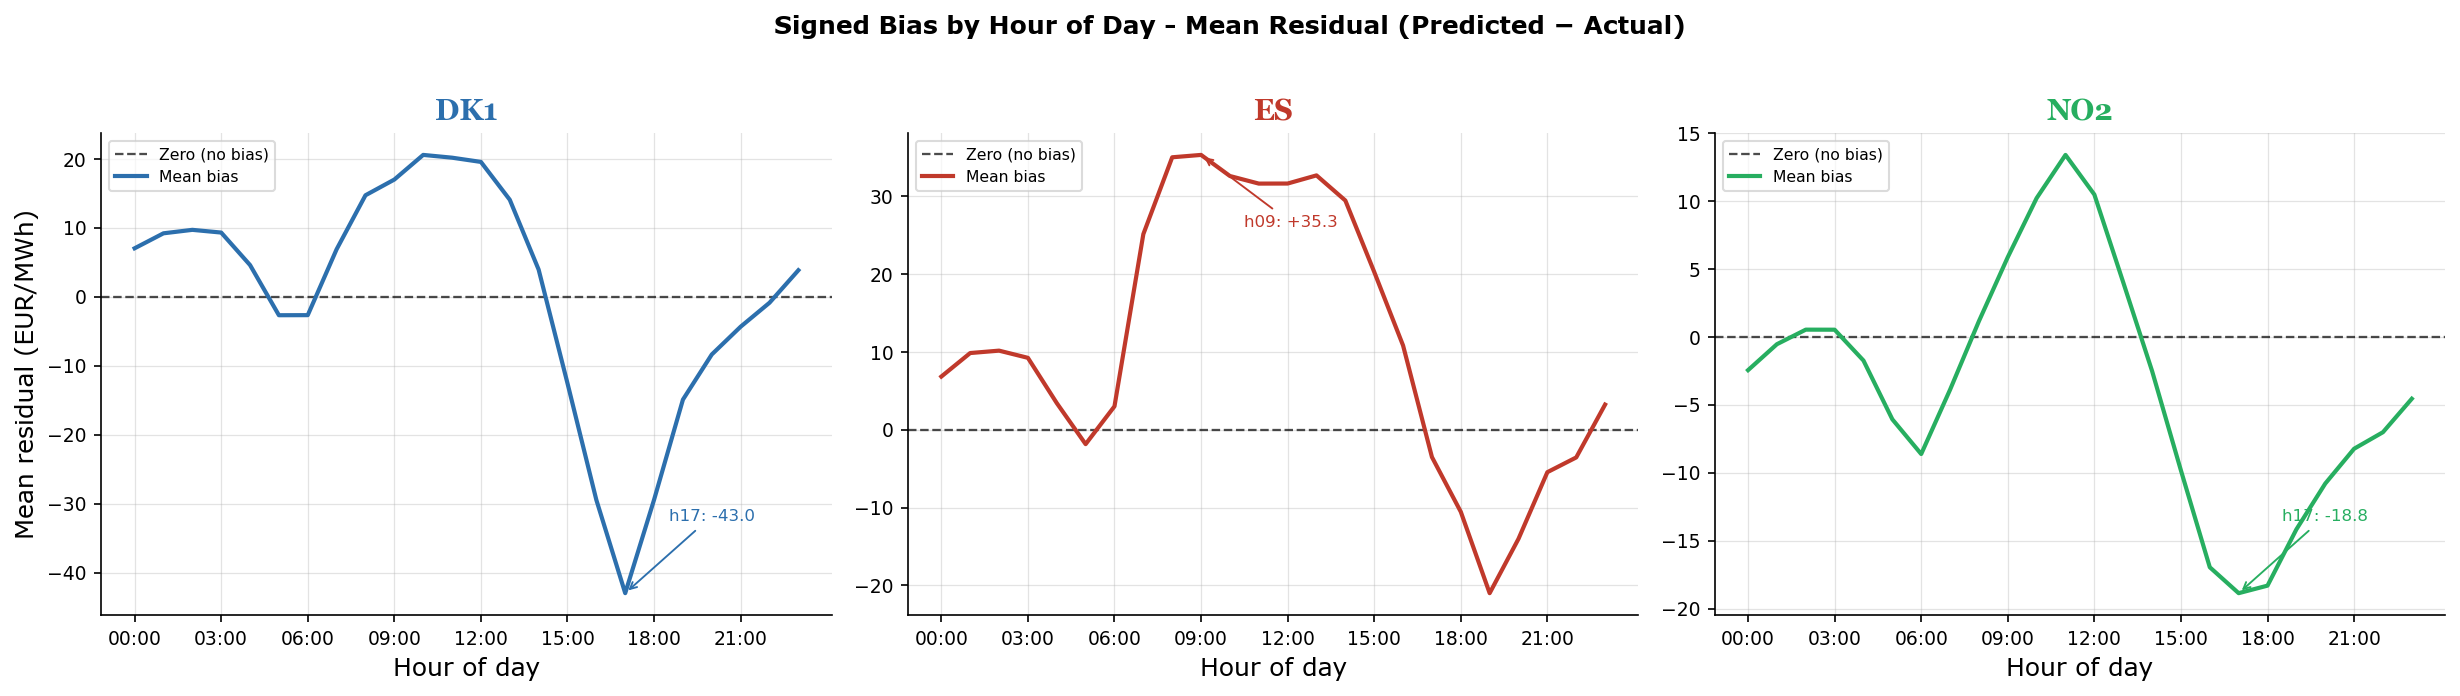

Saved → D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\diagnostics/p2_hourly_bias.png

▶ Plot B: Hour × Price-Bucket


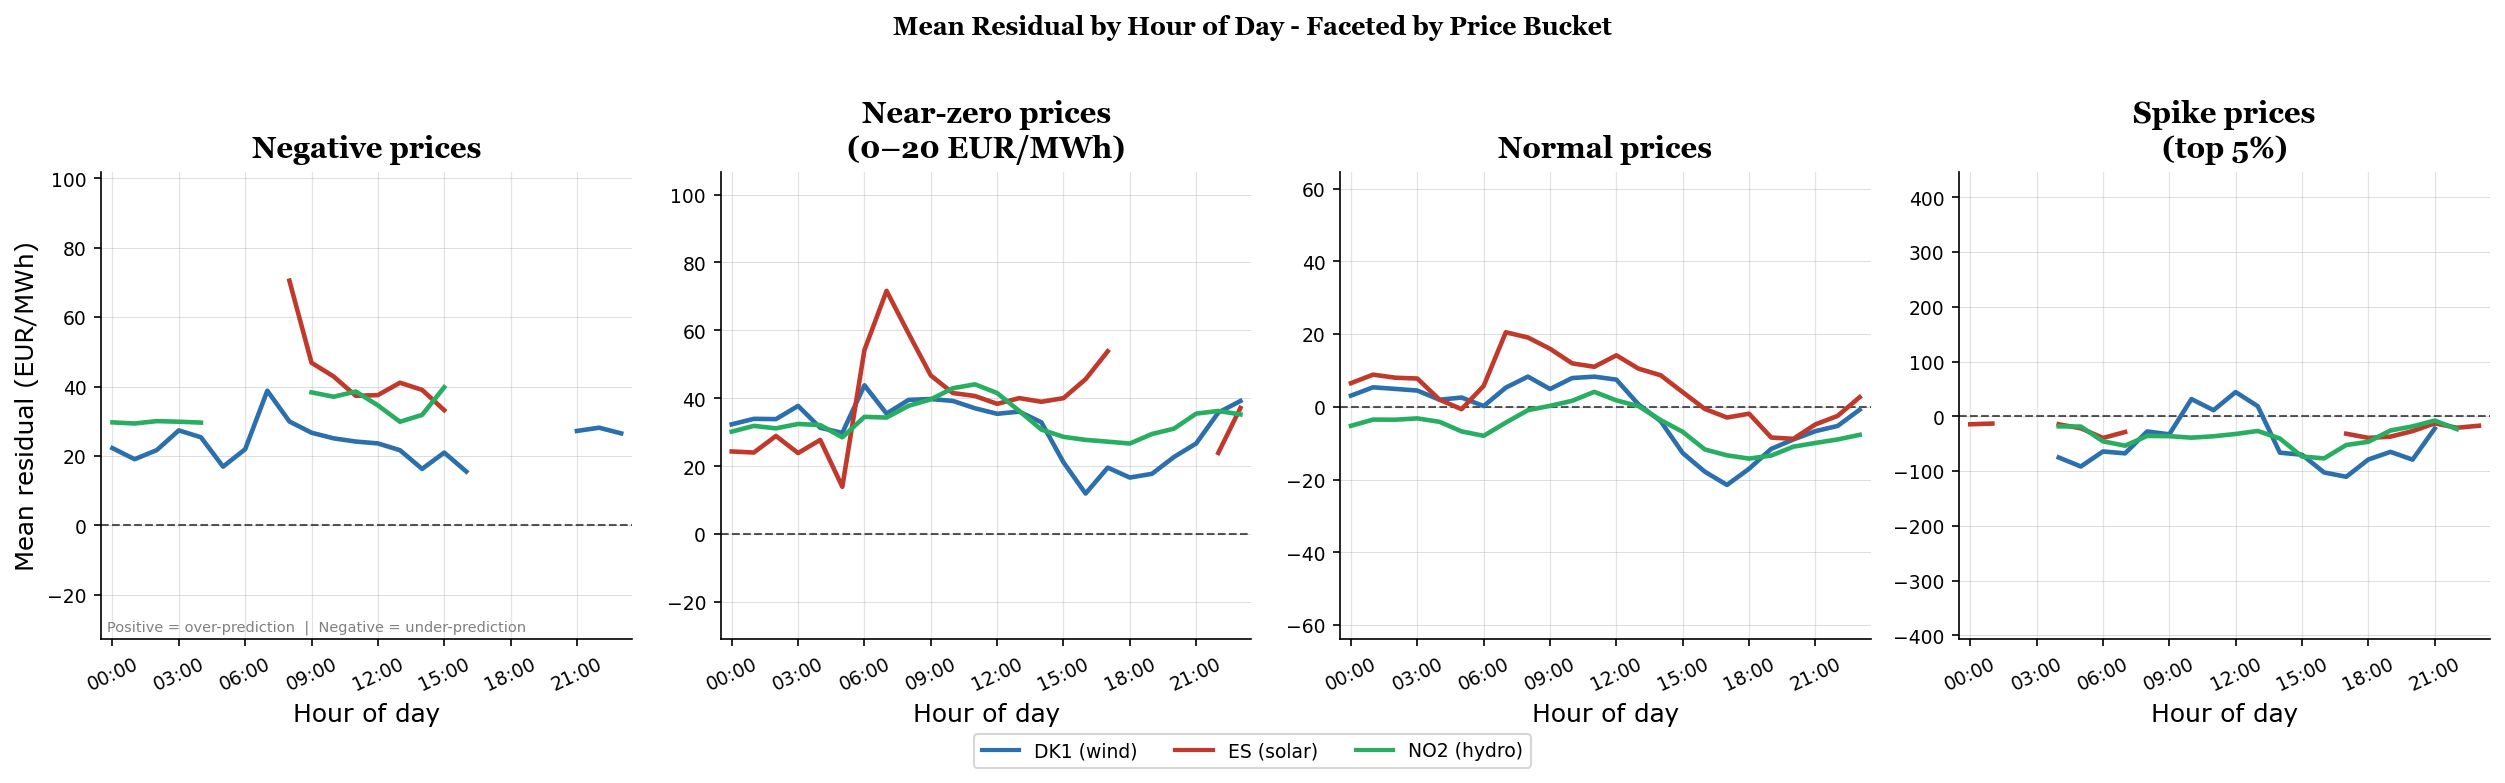

Saved → D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\diagnostics/plot_intraday_residual_by_bucket.png

▶ Table C: Spike hit-rate


,Spike threshold,N hours,Mean residual,Median residual,% under -10 EUR/MWh,% under -20 EUR/MWh,% under -50 EUR/MWh
Zone,,,,,,,
DK1,>144.7 EUR/MWh,201,-77.03,-67.03,92.0%,88.6%,65.7%
ES,>125.2 EUR/MWh,235,-31.34,-26.01,87.2%,62.6%,18.7%
NO2,>98.3 EUR/MWh,196,-41.65,-28.72,85.7%,64.8%,28.1%



▶ Plot C: Spike hit-rate column chart


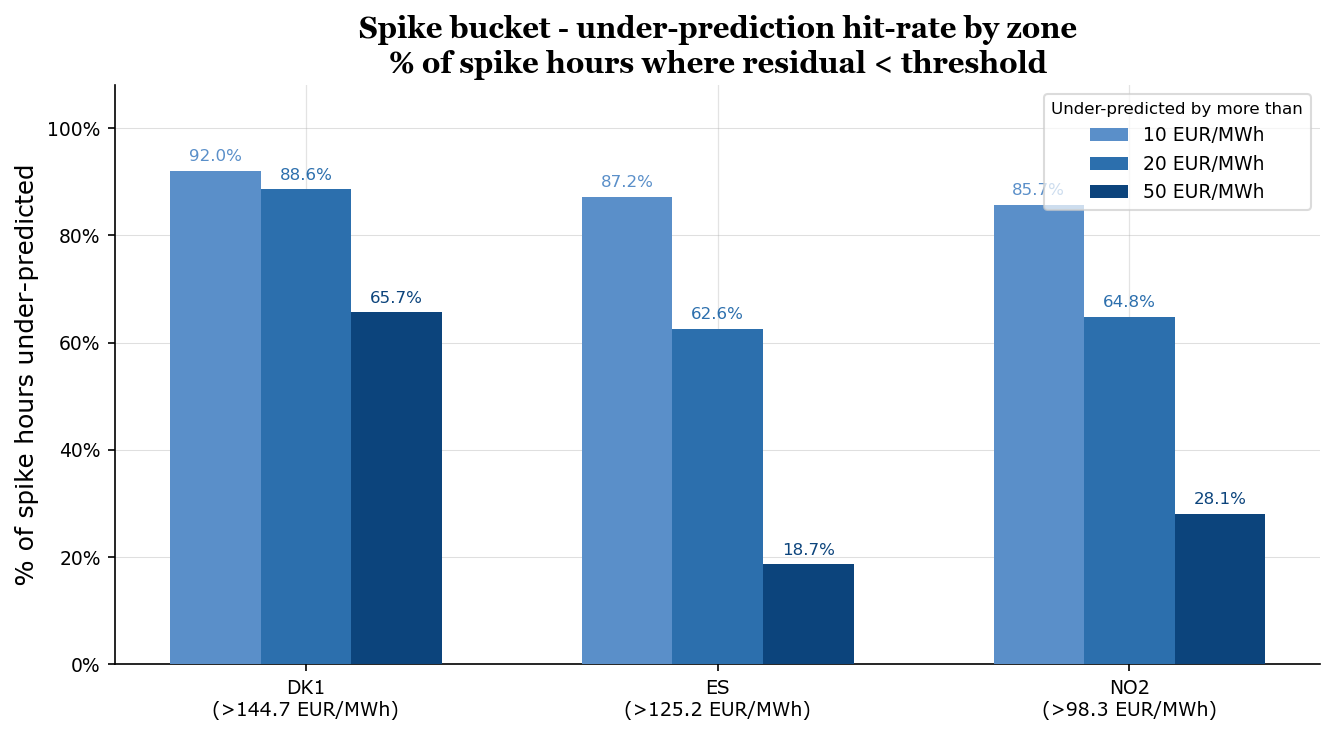

Saved → D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\diagnostics/p2_spike_hit_rate.png

▶ Plot D: Weekday vs Weekend hourly bias


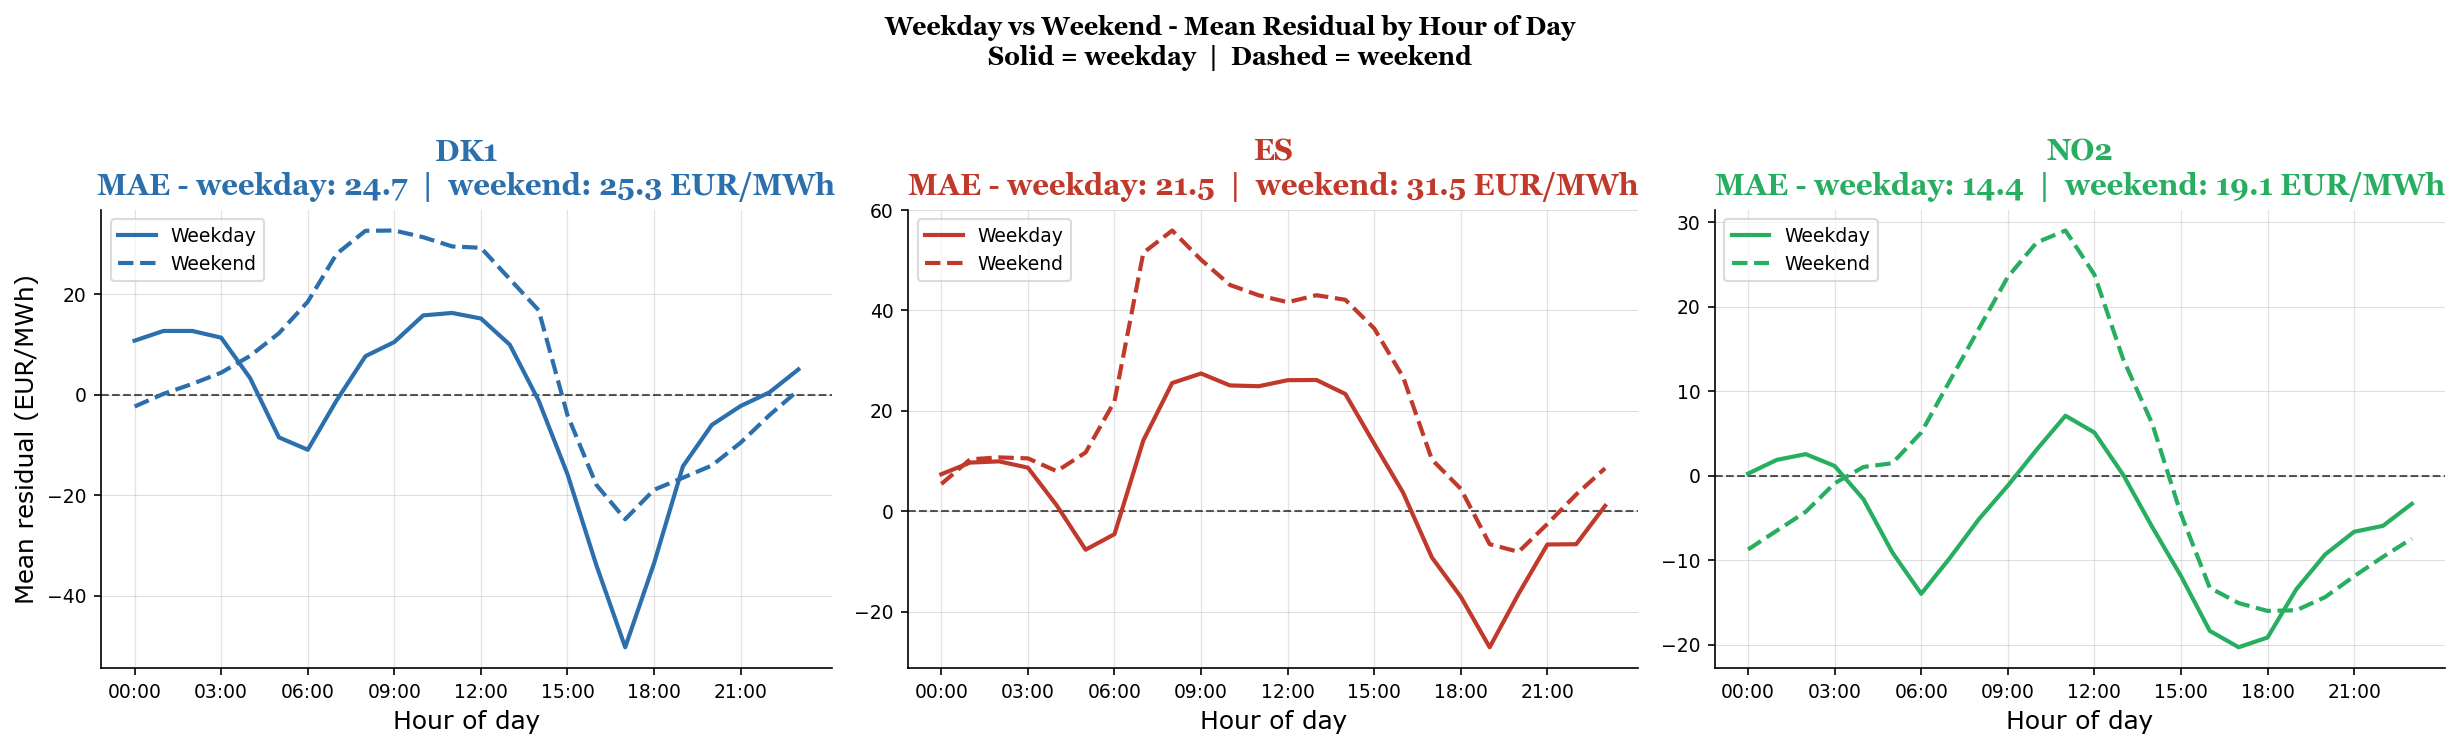

Saved → D:\WU\Semester 6\Data Science 5\DSLab26S-marbl.energy_ACA_AND_PAVLE\DSLab26S-marbl.energy\inherited_pipeline\summary\diagnostics/p2_weekend_weekday.png


In [32]:
# ── 8-B  Run all three Part 2 diagnostics ───────────────────────────────────
#
# Outputs written to DIAG_DIR as:
#   p2_hourly_bias.png
#   p2_bias_heatmap.png
#
# All three are also returned in the `p2_out` dict for further inspection.

DIAG_DIR = str(ROOT / 'diagnostics')

p2_out = p2.run_part2_diagn(
    diag_df,
    spike_quantile  = 0.95,    # top 5% of actual prices = spike
    near_zero_upper = 20.0,    # prices 0–20 EUR/MWh = near-zero
    thresholds      = [-10, -20, -50],
    save_dir        = DIAG_DIR,
)

In [33]:

# Table to check that missing observations in Plot B result from hours being absent in specific price buckets.

check_hours = p2._prepare(diag_df)

check_hours.head()

# Define the full range as a set
all_hours_set = set(range(24))

# 1. Create an empty list to store the rows of our future table
table_data = []

for zone in ZONES.keys():
    for bucket in check_hours["price_bucket"].unique():
        # Convert existing hours to a set
        existing_hours = set(check_hours[(check_hours["price_bucket"] == bucket) & (check_hours["zone"] == zone)]["hour"].unique())
        
        # Subtract existing from all, then sort back into a list
        missing_hours = sorted(list(all_hours_set - existing_hours))
        
        # 2. To make the table look cleaner, let's join the numbers into a string (optional)
        # If there are no missing hours, it will say "None"
        missing_str = ", ".join(map(str, missing_hours)) if missing_hours else "None"
        
        # 3. Append the data as a dictionary (which represents one row in the table)
        table_data.append({
            "Zone": zone,
            "Price Bucket": bucket,
            "Missing Hours": missing_str
        })

# 4. Convert the list into a Pandas DataFrame
missing_hours_df = pd.DataFrame(table_data)

# 5. Display the table
# If you are using a standard Python terminal:
missing_hours_df


,Zone,Price Bucket,Missing Hours
0,DK1,normal,None
1,DK1,near_zero,None
2,DK1,negative,"17, 18, 19, 20"
3,DK1,spike,"0, 1, 2, 3, 22, 23"
4,ES,normal,None
5,ES,near_zero,"18, 19, 20, 21"
6,ES,negative,"0, 1, 2, 3, 4, 5, 6, 7, 16, 17, 18, 19, 20, 21..."
7,ES,spike,"2, 3, 8, 9, 10, 11, 12, 13, 14, 15, 16"
8,NO2,normal,None
9,NO2,near_zero,None


### Hourly Bias - Plot A Analysis

**DK1 (wind-dominated):** The model is broadly unbiased in the early morning but turns sharply negative from midday onward, peaking at −43.0 EUR/MWh at hour 17. This is a clear wind signature: without wind generation forecasts, the model cannot distinguish high-wind (low-price) from low-wind (high-price) evenings, producing large and variable errors throughout the afternoon.

**ES (solar-dominated):** The model over-predicts heavily in the morning, peaking at +35.3 EUR/MWh at hour 09, then reverses into under-prediction during the evening ramp (18:00–21:00). This sign reversal within a single day is the solar noon signature - the model has insufficient signal for the midday supply flood or the subsequent sunset ramp, suggesting solar generation forecasts are likely the highest-impact missing feature for ES

**NO2 (hydro-dominated):** Under-prediction is spread broadly across the afternoon and evening, peaking at −18.8 EUR/MWh at hour 17. Unlike DK1 and ES, the error has no sharp intraday peak, which is consistent with a missing slow-moving driver such as hydro reservoir levels.

In [34]:
# ── 8-C  Inspect hourly summary table (Plot A data) ──────────────────────────
# One row per (zone, hour). Columns: mean, std, count of residuals.
# finds the exact hours with the largest systematic bias.

hourly = p2_out['hourly_summary']

print('Top 5 over-predicted hours (positive mean residual):')
print(
    hourly.nlargest(5, 'mean')[['zone', 'hour', 'mean', 'std', 'count']]
    .to_string(index=False)
)

print('\nTop 5 under-predicted hours (negative mean residual):')
print(
    hourly.nsmallest(5, 'mean')[['zone', 'hour', 'mean', 'std', 'count']]
    .to_string(index=False)
)

Top 5 over-predicted hours (positive mean residual):
zone  hour      mean       std  count
  ES     9 35.337900 23.084470    224
  ES     8 35.032680 28.411947    173
  ES    13 32.705506 20.601887    268
  ES    10 32.624644 21.354355    257
  ES    12 31.658053 19.379012    269

Top 5 under-predicted hours (negative mean residual):
zone  hour       mean       std  count
 DK1    17 -42.951634 60.384606    164
 DK1    16 -29.432681 46.819929    164
 DK1    18 -29.405951 47.214234    163
  ES    19 -21.001417 27.730417    162
 NO2    17 -18.842651 22.678334    163


The data reveals a strong geographical split: the **ES** region suffers from consistent mid-day over-prediction. Conversely, **DK1** dominates the under-prediction list with massive negative residuals during the late afternoon (16:00–18:00), showing significantly higher volatility as indicated by standard deviations reaching 60.38.

### Intraday mean bias per bidding zone - Plot B Analysis
**Systemic overprediction at low prices**: In the "Negative prices" and "Near-zero prices" buckets, all residuals are significantly positive (ranging from 20 to 80 EUR/MWh). This suggests the models consistently fail to capture how low prices actually drop, likely struggling with the "floor" of renewable-driven price crashes.

**Spike underprediction**:Conversely, in the "Spike prices (top 5%)" bucket, residuals are almost entirely negative (down to -100 EUR/MWh). This indicates a chronic under-prediction of price peaks; the model is too "conservative" and misses the full magnitude of extreme volatility.

**Regional Performance**:The Spanish (ES) solar-heavy market shows the highest volatility in residuals. It exhibits a massive over-prediction spike around 06:00–09:00 in the low-price buckets, suggesting the model possibly overestimates the cost of energy during the sunrise ramp-up.

**Market Stability**:The "Normal prices" bucket shows the most balanced performance, with residuals hovering closer to the zero line. Even here, however, there is a visible dip into under-prediction (negative values) during the evening hours (15:00–21:00).

### Spike hit rate - Plot C

**Pervasive Under-prediction**: In all three zones, the models under-predict at least 85% of spike hours by more than 10 EUR/MWh. This confirms that when the market gets tight, the models are almost always too conservative.

**Severe Misses in DK1**: DK1 shows the worst forecasting performance for extreme events. 65.7% of its spikes are under-predicted by more than 50 EUR/MWh. Given its spike threshold is the highest (>144.7 EUR/MWh), these are massive misses in absolute value.

**ES vs. NO2 (Tail Extremes)**:  While ES and NO2 have similar minor under-prediction rates (~86% at the 10 EUR mark), ES is much less likely to have massive errors.

Only 18.7% of Spanish spikes are missed by >50 EUR, whereas Norway misses 28.1% by that same margin.

**The Threshold Factor**: The difficulty of the forecast correlates with the price ceiling of the zone. DK1 has the highest price spikes and, consequently, the most dramatic under-prediction residuals.

### Weekday vs Weekend plot

**Systemic Underestimation**: Across all regions, the models show a significant positive bias (under-prediction) during daylight hours (09:00–15:00), which is consistently more severe on weekends (dashed lines).

**Performance Gap**: Mean Absolute Error (MAE) is higher on weekends for all three regions, with the largest degradation seen in ES (jumping from 21.5 to 31.5 EUR/MWh).

**Evening dip**: All regions exhibit a sharp negative residual (over-prediction) around 17:00–20:00. This suggests the models struggle to account for the rapid drop in demand or price adjustments during the evening transition.

In [ ]:

### we save the model predictions so that we can compare them to the new model later ###

from pathlib import Path

current_dir = Path.cwd()


for zone in list(ZONES.keys()):

    file_path = current_dir / f"old_{zone}_df.parquet"

    globals()[f"old+{zone}+_df"] = pred_dfs[zone].copy()
    
    globals()[f"old+{zone}+_df"].to_parquet(path=file_path, index=False)